In [1]:
# ============================================================
# CELL 0a -- Package Installation
# Run this cell FIRST, then restart the kernel when prompted.
#
# mamba-ssm compiles CUDA kernels from source (~25-45 min on
# Kaggle T4). Set SKIP_MAMBA_SSM = True below to skip that
# and use the notebook's built-in SelectiveSSM fallback.
# The fallback is slower but the entire notebook still runs.
# ============================================================
import sys, subprocess, os, importlib

# ---- USER OPTION ---------------------------------------------------
# True  -> skip mamba-ssm compile; use SelectiveSSM fallback (fast setup)
# False -> compile official CUDA kernels (~25-45 min, best performance)
SKIP_MAMBA_SSM = False
# --------------------------------------------------------------------

def _pip(*args):
    """Silent pip install; returns True on success."""
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', *args],
        capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f'  WARN: {r.stderr.strip()[-500:]}')
    return r.returncode == 0

def _ok(mod):
    try:
        importlib.import_module(mod)
        return True
    except Exception:
        return False

# -- 1. Core scientific stack -----------------------------------------
print("Installing core packages...")
for spec in [
    'scipy>=1.11', 'scikit-learn>=1.4', 'xgboost>=2.0',
    'shap>=0.45', 'matplotlib>=3.8', 'seaborn>=0.13',
    'tqdm>=4.66', 'openpyxl>=3.1',
]:
    _pip(spec)
print('  Core packages ready.')

# -- 2. RDKit ---------------------------------------------------------
print('\nInstalling RDKit...')
if not _ok('rdkit'):
    ok = _pip('rdkit')
    print('  RDKit installed.' if ok else '  RDKit failed -- GNN branch will be unavailable.')
else:
    print('  RDKit already available.')

# -- 3. mamba-ssm (CUDA required, ~25-45 min compile) -----------------
print('\nInstalling mamba-ssm...')
if SKIP_MAMBA_SSM:
    print('  SKIP_MAMBA_SSM=True -- skipping compile.')
    print('  The notebook will use the built-in SelectiveSSM fallback.')
    print('  Set SKIP_MAMBA_SSM=False and re-run this cell to compile the')
    print('  official CUDA kernels for better Mamba performance.')
elif _ok('mamba_ssm'):
    print('  mamba-ssm already available.')
else:
    import torch as _torch
    if _torch.cuda.is_available():
        print(f'  PyTorch {_torch.__version__}, CUDA {_torch.version.cuda}')

        build_env = os.environ.copy()
        build_env['MAX_JOBS'] = '4'

        try:
            major, minor = _torch.cuda.get_device_capability()
            arch = f'{major}.{minor}'
            build_env['TORCH_CUDA_ARCH_LIST'] = arch
            print(f'  GPU arch: sm_{major}{minor}  (TORCH_CUDA_ARCH_LIST={arch})')
        except Exception:
            pass

        _pip('ninja', 'packaging')

        print('  Compiling CUDA kernels -- output streamed live below.')
        print('  causal-conv1d: ~15-25 min    mamba-ssm: ~15-25 min')
        print('  pip prints nothing between "started" and "finished" -- that is normal.')
        print('  ' + '-' * 60)
        r_mamba = subprocess.run(
            [sys.executable, '-m', 'pip', 'install',
             '--no-build-isolation', 'causal-conv1d>=1.4.0', 'mamba-ssm'],
            env=build_env
        )
        print('  ' + '-' * 60)
        if r_mamba.returncode == 0:
            print('  mamba-ssm installed. Continue running the notebook.')
        else:
            print('  mamba-ssm build failed -- SelectiveSSM fallback will be used.')
    else:
        print('  No CUDA GPU -- using SelectiveSSM fallback.')

# -- 4. torch-geometric (optional GNN branch) -------------------------
print('\nInstalling torch-geometric...')
if not _ok('torch_geometric'):
    import torch as _torch
    torch_ver = _torch.__version__.split('+')[0]
    cuda_ver  = _torch.version.cuda

    ok_base = _pip('torch-geometric')
    if ok_base and cuda_ver:
        cuda_tag = 'cu' + cuda_ver.replace('.', '')
        parts    = torch_ver.split('.')
        tv       = '.'.join(parts[:3]) if len(parts) >= 3 else torch_ver
        pyg_url  = f'https://data.pyg.org/whl/torch-{tv}+{cuda_tag}.html'
        print(f'  Installing PyG sparse wheels for torch={tv} cuda={cuda_tag}')
        ok_sparse = _pip('torch-scatter', 'torch-sparse', 'torch-cluster',
                         'torch-spline-conv', '-f', pyg_url)
        if not ok_sparse:
            print('  Sparse wheels unavailable for this combo; base PyG still usable.')
    if ok_base:
        print('  torch-geometric installed.')
    else:
        print('  torch-geometric failed -- GNN branch unavailable.')
else:
    print('  torch-geometric already available.')

# -- 5. DeepChem (MoleculeNet datasets) --------------------------------
print('\nInstalling deepchem...')
if not _ok('deepchem'):
    ok_dc = _pip('deepchem')
    print('  deepchem installed.' if ok_dc else '  deepchem failed -- MoleculeNet cell will be skipped.')
else:
    print('  deepchem already available.')

# -- Summary ----------------------------------------------------------
print('\n== Package status ==')
for label, mod in [
    ('numpy',           'numpy'),
    ('pandas',          'pandas'),
    ('scipy',           'scipy'),
    ('scikit-learn',    'sklearn'),
    ('xgboost',         'xgboost'),
    ('shap',            'shap'),
    ('matplotlib',      'matplotlib'),
    ('seaborn',         'seaborn'),
    ('tqdm',            'tqdm'),
    ('openpyxl',        'openpyxl'),
    ('torch',           'torch'),
    ('rdkit',           'rdkit'),
    ('mamba-ssm',       'mamba_ssm'),
    ('torch-geometric', 'torch_geometric'),
    ('deepchem',        'deepchem'),
]:
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, '__version__', '?')
        print(f'  [OK] {label:<18} {ver}')
    except Exception:
        print(f'  [--] {label:<18} not available (fallback will be used)')

print('\nInstallation complete.')
print('All packages ready -- continue running the notebook.')

Installing core packages...
  Core packages ready.

Installing RDKit...
  RDKit installed.

Installing mamba-ssm...
  PyTorch 2.10.0+cu128, CUDA 12.8
  GPU arch: sm_75  (TORCH_CUDA_ARCH_LIST=7.5)
  Compiling CUDA kernels -- output streamed live below.
  causal-conv1d: ~15-25 min    mamba-ssm: ~15-25 min
  pip prints nothing between "started" and "finished" -- that is normal.
  ------------------------------------------------------------
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━

2026-05-17 06:25:24.688783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778999124.875412      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778999124.930016      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778999125.379367      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778999125.379431      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778999125.379437      57 computation_placer.cc:177] computation placer alr

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


  [OK] deepchem           2.5.0

Installation complete.
All packages ready -- continue running the notebook.


In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
import os
print(os.listdir("/kaggle/input/datasets/shabbirmahmood/ssvep-benchmark-dataset"))

['S2.mat', 'S19.mat', 'S24.mat', 'S5.mat', 'S6.mat', 'S23.mat', 'S15.mat', 'S22.mat', 'S10.mat', '64-channels.loc', 'S30.mat', 'S35.mat', 'S18.mat', 'S8.mat', 'S17.mat', 'S25.mat', 'S16.mat', 'S27.mat', 'S7.mat', 'Readme.txt', 'S14.mat', 'S13.mat', 'S31.mat', 'S33.mat', 'S1.mat', 'S29.mat', 'S28.mat', 'Freq_Phase.mat', 'S3.mat', 'S21.mat', 'RMAOV2.m', 'S26.mat', 'S20.mat', 'S4.mat', 'Sub_info.txt', 'S32.mat', 'S12.mat', 'S11.mat', 'S34.mat', 'S9.mat']


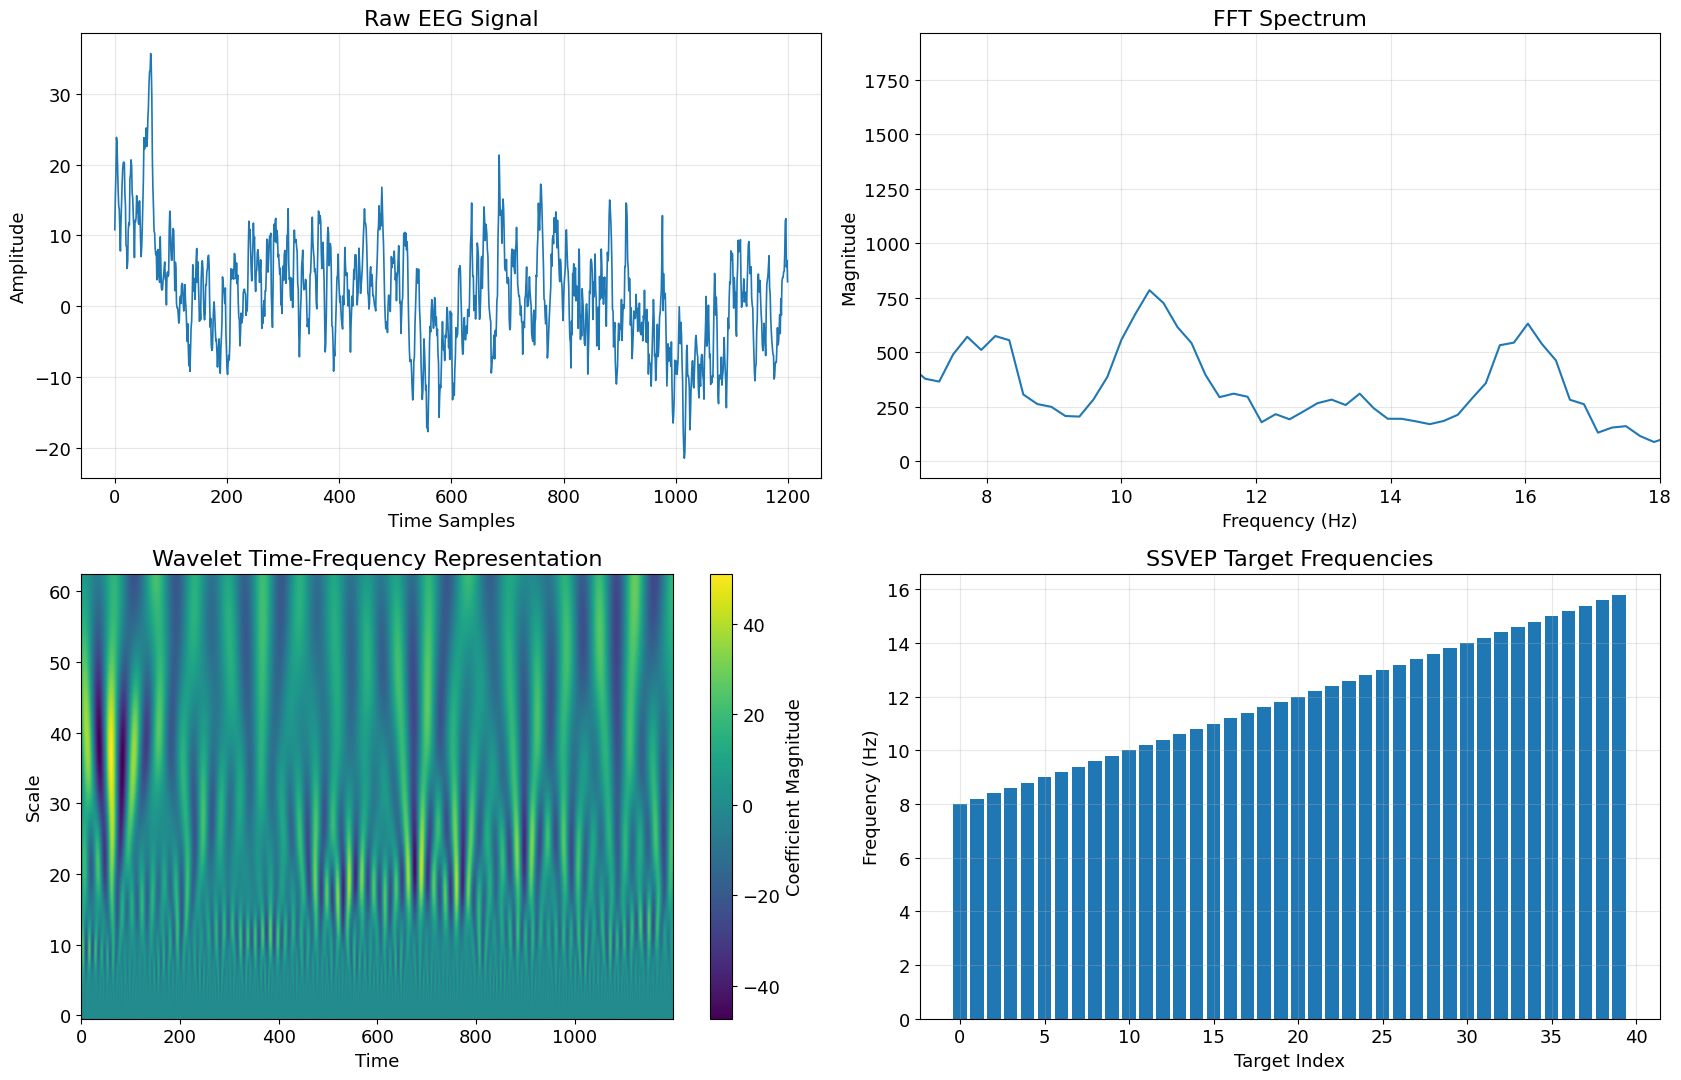

In [10]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pywt

# ============================================================
# PUBLICATION STYLE
# ============================================================

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 13
})

# ============================================================
# DATASET PATH
# ============================================================

dataset_path = "/kaggle/input/datasets/shabbirmahmood/ssvep-benchmark-dataset"

# ============================================================
# LOAD SUBJECT FILES ONLY
# ============================================================

files = sorted([
    f for f in os.listdir(dataset_path)
    if f.startswith("S") and f.endswith(".mat")
])

# ============================================================
# LOAD SUBJECT
# ============================================================

mat = sio.loadmat(
    os.path.join(dataset_path, files[0])
)

# ============================================================
# EEG DATA
# ============================================================

data = mat['data']

# Shape:
# (64, 1500, 40, 6)

# ============================================================
# SELECT EEG SAMPLE
# ============================================================

# Occipital channel (strong SSVEP activity)
channel = 61

target = 0
block = 0

signal = data[channel, :, target, block]

# ============================================================
# REMOVE END ARTIFACTS
# ============================================================

signal = signal[:1200]

# ============================================================
# SAMPLING RATE
# ============================================================

fs = 250

# ============================================================
# FFT
# ============================================================

freqs = np.fft.rfftfreq(
    len(signal),
    d=1/fs
)

fft_vals = np.abs(
    np.fft.rfft(signal)
)

# ------------------------------------------------------------
# FFT SMOOTHING
# ------------------------------------------------------------

fft_vals = np.convolve(
    fft_vals,
    np.ones(5)/5,
    mode='same'
)

# ============================================================
# WAVELET TRANSFORM
# ============================================================

coeffs, freqs_wavelet = pywt.cwt(
    signal,
    scales=np.arange(1, 64),
    wavelet='morl'
)

# ============================================================
# SSVEP TARGETS
# ============================================================

targets = np.arange(
    8.0,
    15.8 + 0.2,
    0.2
)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 11)
)

# ============================================================
# RAW EEG SIGNAL
# ============================================================

axes[0,0].plot(
    signal,
    linewidth=1.2
)

axes[0,0].set_title(
    "Raw EEG Signal"
)

axes[0,0].set_xlabel(
    "Time Samples"
)

axes[0,0].set_ylabel(
    "Amplitude"
)

axes[0,0].grid(
    alpha=0.3
)

# ============================================================
# FFT SPECTRUM
# ============================================================

axes[0,1].plot(
    freqs,
    fft_vals,
    linewidth=1.5
)

# Focus on SSVEP range
axes[0,1].set_xlim(7, 18)

axes[0,1].set_title(
    "FFT Spectrum"
)

axes[0,1].set_xlabel(
    "Frequency (Hz)"
)

axes[0,1].set_ylabel(
    "Magnitude"
)

axes[0,1].grid(
    alpha=0.3
)

# ============================================================
# WAVELET REPRESENTATION
# ============================================================

im = axes[1,0].imshow(
    coeffs,
    aspect='auto',
    cmap='viridis',
    origin='lower'
)

axes[1,0].set_title(
    "Wavelet Time-Frequency Representation"
)

axes[1,0].set_xlabel(
    "Time"
)

axes[1,0].set_ylabel(
    "Scale"
)

cbar = fig.colorbar(
    im,
    ax=axes[1,0]
)

cbar.ax.set_ylabel(
    "Coefficient Magnitude"
)

# ============================================================
# SSVEP TARGET FREQUENCIES
# ============================================================

axes[1,1].bar(
    np.arange(len(targets)),
    targets,
    width=0.8
)

axes[1,1].set_title(
    "SSVEP Target Frequencies"
)

axes[1,1].set_xlabel(
    "Target Index"
)

axes[1,1].set_ylabel(
    "Frequency (Hz)"
)

axes[1,1].grid(
    alpha=0.3
)

# ============================================================
# IMPROVE SPACING
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE HIGH-QUALITY FIGURE
# ============================================================

plt.savefig(
    "dataset_samples.png",
    dpi=600,
    bbox_inches='tight'
)

# ============================================================
# SHOW FIGURE
# ============================================================

plt.show()

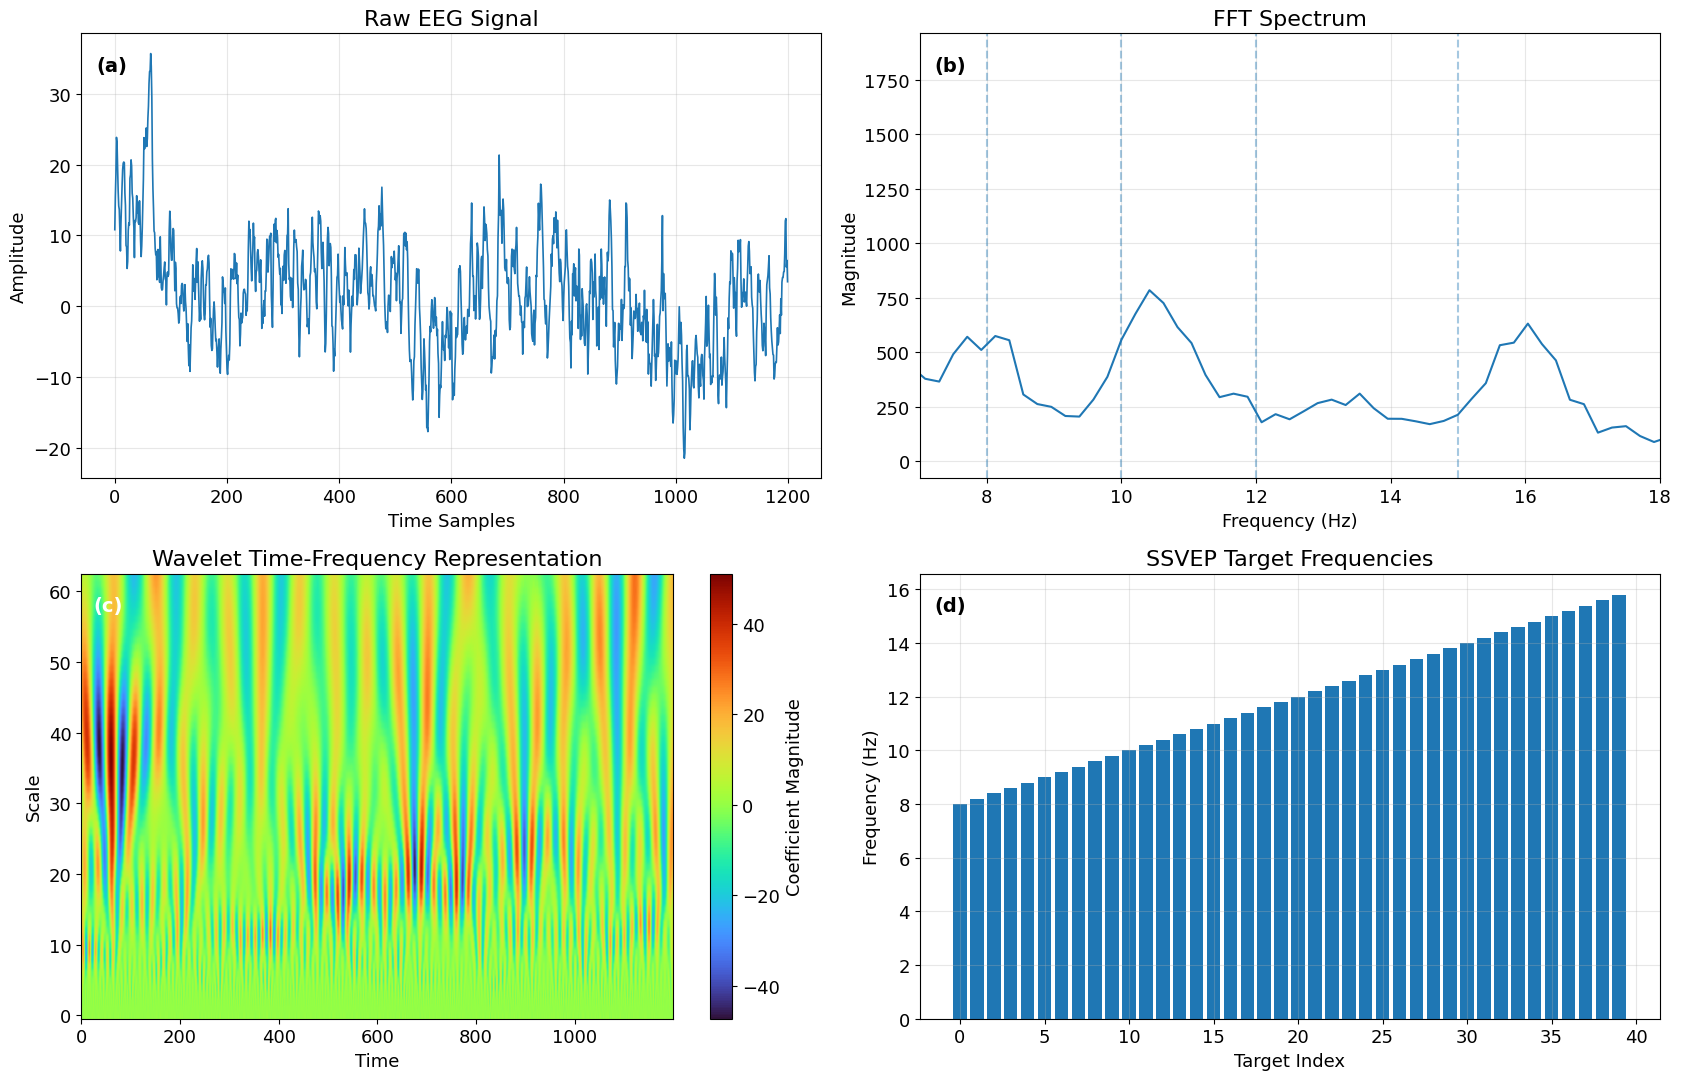

In [11]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pywt

# ============================================================
# PUBLICATION STYLE
# ============================================================

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 13
})

# ============================================================
# DATASET PATH
# ============================================================

dataset_path = "/kaggle/input/datasets/shabbirmahmood/ssvep-benchmark-dataset"

# ============================================================
# LOAD SUBJECT FILES
# ============================================================

files = sorted([
    f for f in os.listdir(dataset_path)
    if f.startswith("S") and f.endswith(".mat")
])

# ============================================================
# LOAD SUBJECT
# ============================================================

mat = sio.loadmat(
    os.path.join(dataset_path, files[0])
)

# ============================================================
# LOAD EEG DATA
# ============================================================

data = mat['data']

# Shape:
# (64, 1500, 40, 6)

# ============================================================
# SELECT EEG SAMPLE
# ============================================================

# Occipital EEG channel
channel = 61

target = 0
block = 0

signal = data[channel, :, target, block]

# ============================================================
# REMOVE END ARTIFACTS
# ============================================================

signal = signal[:1200]

# ============================================================
# SAMPLING RATE
# ============================================================

fs = 250

# ============================================================
# FFT ANALYSIS
# ============================================================

freqs = np.fft.rfftfreq(
    len(signal),
    d=1/fs
)

fft_vals = np.abs(
    np.fft.rfft(signal)
)

# ------------------------------------------------------------
# FFT SMOOTHING
# ------------------------------------------------------------

fft_vals = np.convolve(
    fft_vals,
    np.ones(5)/5,
    mode='same'
)

# ============================================================
# WAVELET TRANSFORM
# ============================================================

coeffs, freqs_wavelet = pywt.cwt(
    signal,
    scales=np.arange(1, 64),
    wavelet='morl'
)

# ============================================================
# TARGET FREQUENCIES
# ============================================================

targets = np.arange(
    8.0,
    15.8 + 0.2,
    0.2
)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 11)
)

# ============================================================
# (a) RAW EEG SIGNAL
# ============================================================

axes[0,0].plot(
    signal,
    linewidth=1.2
)

axes[0,0].set_title(
    "Raw EEG Signal"
)

axes[0,0].set_xlabel(
    "Time Samples"
)

axes[0,0].set_ylabel(
    "Amplitude"
)

axes[0,0].grid(alpha=0.3)

axes[0,0].text(
    0.02,
    0.95,
    '(a)',
    transform=axes[0,0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top'
)

# ============================================================
# (b) FFT SPECTRUM
# ============================================================

axes[0,1].plot(
    freqs,
    fft_vals,
    linewidth=1.5
)

# Focus on SSVEP range
axes[0,1].set_xlim(7, 18)

# Highlight example SSVEP frequencies
for f in [8, 10, 12, 15]:
    axes[0,1].axvline(
        f,
        linestyle='--',
        alpha=0.4
    )

axes[0,1].set_title(
    "FFT Spectrum"
)

axes[0,1].set_xlabel(
    "Frequency (Hz)"
)

axes[0,1].set_ylabel(
    "Magnitude"
)

axes[0,1].grid(alpha=0.3)

axes[0,1].text(
    0.02,
    0.95,
    '(b)',
    transform=axes[0,1].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top'
)

# ============================================================
# (c) WAVELET REPRESENTATION
# ============================================================

im = axes[1,0].imshow(
    coeffs,
    aspect='auto',
    cmap='turbo',
    origin='lower'
)

axes[1,0].set_title(
    "Wavelet Time-Frequency Representation"
)

axes[1,0].set_xlabel(
    "Time"
)

axes[1,0].set_ylabel(
    "Scale"
)

cbar = fig.colorbar(
    im,
    ax=axes[1,0]
)

cbar.ax.set_ylabel(
    "Coefficient Magnitude"
)

axes[1,0].text(
    0.02,
    0.95,
    '(c)',
    transform=axes[1,0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    color='white'
)

# ============================================================
# (d) SSVEP TARGET FREQUENCIES
# ============================================================

axes[1,1].bar(
    np.arange(len(targets)),
    targets,
    width=0.8
)

axes[1,1].set_title(
    "SSVEP Target Frequencies"
)

axes[1,1].set_xlabel(
    "Target Index"
)

axes[1,1].set_ylabel(
    "Frequency (Hz)"
)

axes[1,1].grid(alpha=0.3)

axes[1,1].text(
    0.02,
    0.95,
    '(d)',
    transform=axes[1,1].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top'
)

# ============================================================
# IMPROVE LAYOUT
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE HIGH-RESOLUTION FIGURE
# ============================================================

plt.savefig(
    "dataset_samples.png",
    dpi=600,
    bbox_inches='tight'
)

# ============================================================
# SHOW FIGURE
# ============================================================

plt.show()

In [4]:
from scipy.io import loadmat
import os

data_path = "/kaggle/input/datasets/shabbirmahmood/ssvep-benchmark-dataset"

file_path = os.path.join(data_path, "S1.mat")  # example subject

mat = loadmat(file_path)

print(mat.keys())  # see what's inside

dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [5]:
eeg = mat['data']  # 👈 FIX HERE
print(type(eeg))
print(eeg.shape)

<class 'numpy.ndarray'>
(64, 1500, 40, 6)


In [6]:
import numpy as np
def load_ssvep_data(data_path):

    X = []
    y = []
    subjects = []

    for subject in range(1, 36):

        print(f"Loading Subject S{subject}...")

        mat = loadmat(f"{data_path}/S{subject}.mat")

        data = mat['data']

        # Shape:
        # (64 channels, 1500 samples, 40 targets, 6 trials)

        for target in range(40):

            for trial in range(6):

                # ------------------------------------------------
                # TRANSPOSE:
                # Original: (64, 1500)
                # New:      (1500, 64)
                # ------------------------------------------------

                sample = data[:, :, target, trial].T

                X.append(sample)

                y.append(target)

                subjects.append(subject)

    X = np.array(X, dtype=np.float32)

    y = np.array(y)

    subjects = np.array(subjects)

    return X, y, subjects

In [7]:
X_raw, y, subjects = load_ssvep_data(data_path)

Loading Subject S1...
Loading Subject S2...
Loading Subject S3...
Loading Subject S4...
Loading Subject S5...
Loading Subject S6...
Loading Subject S7...
Loading Subject S8...
Loading Subject S9...
Loading Subject S10...
Loading Subject S11...
Loading Subject S12...
Loading Subject S13...
Loading Subject S14...
Loading Subject S15...
Loading Subject S16...
Loading Subject S17...
Loading Subject S18...
Loading Subject S19...
Loading Subject S20...
Loading Subject S21...
Loading Subject S22...
Loading Subject S23...
Loading Subject S24...
Loading Subject S25...
Loading Subject S26...
Loading Subject S27...
Loading Subject S28...
Loading Subject S29...
Loading Subject S30...
Loading Subject S31...
Loading Subject S32...
Loading Subject S33...
Loading Subject S34...
Loading Subject S35...


In [8]:
print("\n================================================")
print("DATASET INFORMATION")
print("================================================")

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)

print("\nSample shape:")
print(X_raw[0].shape)

print("\nUnique classes:")
print(len(np.unique(y)))

print("\nUnique subjects:")
print(len(np.unique(subjects)))


DATASET INFORMATION
X_raw shape: (8400, 1500, 64)
y shape: (8400,)
subjects shape: (8400,)

Sample shape:
(1500, 64)

Unique classes:
40

Unique subjects:
35


In [13]:
# ============================================================
# FEATURE EXTRACTION
# ============================================================

from scipy.signal import welch
from scipy.stats import entropy
import pywt

# ============================================================
# EEG FREQUENCY BANDS
# ============================================================

EEG_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 50)
}

In [14]:
# ============================================================
# FFT FEATURES
# ============================================================

def extract_fft_features(signal, fs=250):

    """
    signal shape:
    (time, channels)
    """

    fft_vals = np.abs(np.fft.rfft(signal, axis=0))

    freqs = np.fft.rfftfreq(signal.shape[0], d=1/fs)

    # Keep 1–50 Hz
    mask = (freqs >= 1) & (freqs <= 50)

    fft_vals = fft_vals[mask]

    return fft_vals.flatten()

In [15]:
# ============================================================
# BANDPOWER FEATURES
# ============================================================

def extract_bandpower_features(signal, fs=250):

    features = []

    for ch in range(signal.shape[1]):

        freqs, psd = welch(
            signal[:, ch],
            fs=fs,
            nperseg=fs*2
        )

        total_power = np.sum(psd) + 1e-8

        for band_name, (low, high) in EEG_BANDS.items():

            idx = (freqs >= low) & (freqs <= high)

            band_power = np.sum(psd[idx])

            relative_power = band_power / total_power

            features.extend([
                band_power,
                relative_power
            ])

    return np.array(features)


In [16]:
# SPECTRAL ENTROPY
# ============================================================

def extract_spectral_entropy(signal, fs=250):

    features = []

    for ch in range(signal.shape[1]):

        freqs, psd = welch(
            signal[:, ch],
            fs=fs
        )

        psd_norm = psd / (np.sum(psd) + 1e-8)

        spec_entropy = entropy(psd_norm)

        features.append(spec_entropy)

    return np.array(features)

In [17]:
# ============================================================
# HJORTH PARAMETERS
# ============================================================

def hjorth_parameters(x):

    first_deriv = np.diff(x)
    second_deriv = np.diff(first_deriv)

    var_zero = np.var(x)
    var_d1 = np.var(first_deriv)
    var_d2 = np.var(second_deriv)

    mobility = np.sqrt(var_d1 / (var_zero + 1e-8))

    complexity = np.sqrt(var_d2 / (var_d1 + 1e-8)) / (mobility + 1e-8)

    return mobility, complexity

def extract_hjorth_features(signal):

    features = []

    for ch in range(signal.shape[1]):

        mobility, complexity = hjorth_parameters(signal[:, ch])

        features.extend([
            mobility,
            complexity
        ])

    return np.array(features)

In [18]:
# ============================================================
# WAVELET FEATURES
# ============================================================

def extract_wavelet_features(signal):

    features = []

    for ch in range(signal.shape[1]):

        coeffs = pywt.wavedec(
            signal[:, ch],
            wavelet='db4',
            level=4
        )

        for coeff in coeffs:

            features.extend([
                np.mean(coeff),
                np.std(coeff),
                np.var(coeff),
                np.max(coeff),
                np.min(coeff),
                np.sum(coeff**2)
            ])

    return np.array(features)

In [19]:
# ============================================================
# FULL FEATURE EXTRACTION
# ============================================================

def extract_all_features(signal):

    fft_features = extract_fft_features(signal)

    bandpower_features = extract_bandpower_features(signal)

    entropy_features = extract_spectral_entropy(signal)

    hjorth_features = extract_hjorth_features(signal)

    wavelet_features = extract_wavelet_features(signal)

    # --------------------------------------------------------
    # FEATURE FUSION
    # --------------------------------------------------------

    fused_features = np.concatenate([
        fft_features,
        bandpower_features,
        entropy_features,
        hjorth_features,
        wavelet_features
    ])

    return fused_features

In [20]:
# ============================================================
# EXTRACT FEATURES FOR FULL DATASET
# ============================================================

X_features = []

for i in range(len(X_raw)):

    if i % 500 == 0:
        print(f"Processing sample {i}/{len(X_raw)}")

    features = extract_all_features(X_raw[i])

    X_features.append(features)

X_features = np.array(X_features)

Processing sample 0/8400
Processing sample 500/8400
Processing sample 1000/8400
Processing sample 1500/8400
Processing sample 2000/8400
Processing sample 2500/8400
Processing sample 3000/8400
Processing sample 3500/8400
Processing sample 4000/8400
Processing sample 4500/8400
Processing sample 5000/8400
Processing sample 5500/8400
Processing sample 6000/8400
Processing sample 6500/8400
Processing sample 7000/8400
Processing sample 7500/8400
Processing sample 8000/8400


In [21]:
# ============================================================
# FEATURE INFORMATION
# ============================================================

print("\n================================================")
print("FEATURE EXTRACTION COMPLETE")
print("================================================")

print("Feature matrix shape:")
print(X_features.shape)

print("\nFeature vector shape:")
print(X_features[0].shape)

print("\nFeature types included:")
print("- FFT features")
print("- Bandpower features")
print("- Spectral entropy")
print("- Hjorth parameters")
print("- Wavelet features")


FEATURE EXTRACTION COMPLETE
Feature matrix shape:
(8400, 21632)

Feature vector shape:
(21632,)

Feature types included:
- FFT features
- Bandpower features
- Spectral entropy
- Hjorth parameters
- Wavelet features


In [22]:
# ============================================================
# FEATURE NORMALIZATION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_features)

print("Normalized feature shape:")
print(X_scaled.shape)


Normalized feature shape:
(8400, 21632)


In [23]:
# ============================================================
# PCA REDUCTION (FASTER + MORE PRACTICAL)
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# FIXED NUMBER OF COMPONENTS
# Much faster than 95% variance PCA
# ------------------------------------------------------------

pca = PCA(
    n_components=512,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print("\n================================================")
print("PCA RESULTS")
print("================================================")

print("Original shape:")
print(X_scaled.shape)

print("\nReduced shape:")
print(X_pca.shape)

# ------------------------------------------------------------
# EXPLAINED VARIANCE
# ------------------------------------------------------------

explained_variance = np.sum(
    pca.explained_variance_ratio_
)

print("\nExplained variance:")
print(explained_variance)


PCA RESULTS
Original shape:
(8400, 21632)

Reduced shape:
(8400, 512)

Explained variance:
0.7220944


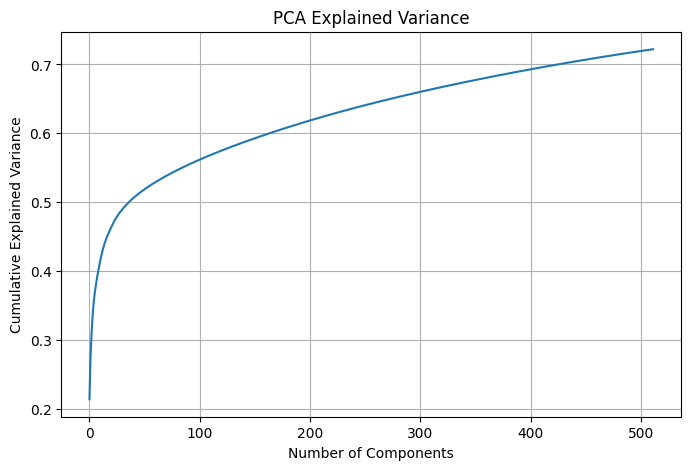

In [20]:
# ============================================================
# OPTIONAL: EXPLAINED VARIANCE PLOT
# ============================================================

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(cumulative_variance)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


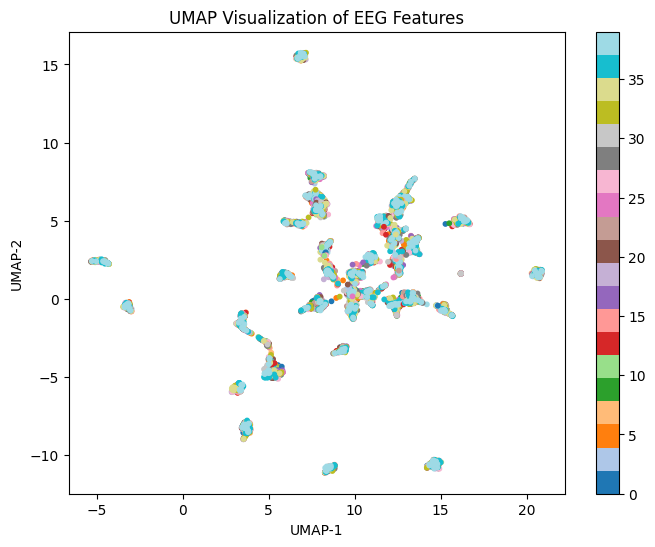

In [21]:
# ============================================================
# UMAP VISUALIZATION
# ============================================================

import umap.umap_ as umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y,
    cmap='tab20',
    s=10
)

plt.title("UMAP Visualization of EEG Features")

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.colorbar(scatter)

plt.show()

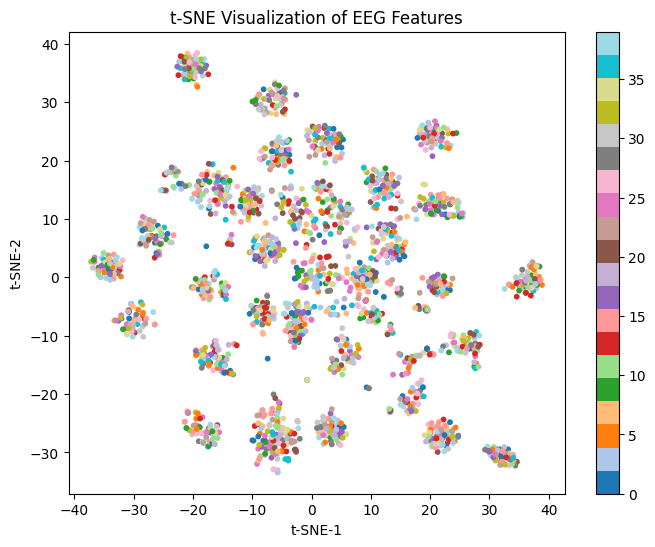

In [22]:
# ============================================================
# t-SNE VISUALIZATION
# ============================================================

from sklearn.manifold import TSNE

# Use subset because t-SNE is expensive
subset_size = 2000

indices = np.random.choice(
    len(X_scaled),
    subset_size,
    replace=False
)

X_subset = X_scaled[indices]
y_subset = y[indices]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_subset)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_subset,
    cmap='tab20',
    s=10
)

plt.title("t-SNE Visualization of EEG Features")

plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")

plt.colorbar(scatter)

plt.show()

In [23]:
# ============================================================
# FEATURE SELECTION
# ============================================================

from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import ElasticNetCV

# ============================================================
# L1 FEATURE SELECTION
# ============================================================

print("================================================")
print("L1 FEATURE SELECTION")
print("================================================")

l1_selector_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=1.0,
    max_iter=500,
    n_jobs=-1
)

l1_selector_model.fit(X_pca, y)

l1_selector = SelectFromModel(
    l1_selector_model,
    prefit=True
)

X_l1 = l1_selector.transform(X_pca)

print("Original PCA shape:")
print(X_pca.shape)

print("\nL1 selected shape:")
print(X_l1.shape)

L1 FEATURE SELECTION
Original PCA shape:
(8400, 512)

L1 selected shape:
(8400, 512)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [24]:
# # ============================================================
# # L2 REGULARIZATION
# # ============================================================

# print("\n================================================")
# print("L2 REGULARIZATION")
# print("================================================")

# l2_model = LogisticRegression(
#     penalty='l2',
#     solver='lbfgs',
#     C=1.0,
#     max_iter=500,
#     n_jobs=-1
# )

# l2_model.fit(X_pca, y)

# print("L2 model trained successfully.")

In [25]:
# # ============================================================
# # ELASTIC NET FEATURE SELECTION
# # ============================================================

# print("\n================================================")
# print("ELASTIC NET FEATURE SELECTION")
# print("================================================")

# elastic_model = LogisticRegression(
#     penalty='elasticnet',
#     solver='saga',
#     l1_ratio=0.5,
#     C=0.1,
#     max_iter=500,
#     n_jobs=-1
# )

# elastic_model.fit(X_pca, y)

# elastic_selector = SelectFromModel(
#     elastic_model,
#     prefit=True
# )

# X_elastic = elastic_selector.transform(X_pca)

# print("Original PCA shape:")
# print(X_pca.shape)

# print("\nElasticNet selected shape:")
# print(X_elastic.shape)

In [26]:
# # ============================================================
# # FEATURE SELECTION COMPARISON
# # ============================================================

# print("\n================================================")
# print("FEATURE SELECTION SUMMARY")
# print("================================================")

# print(f"PCA Features:        {X_pca.shape[1]}")
# print(f"L1 Selected:         {X_l1.shape[1]}")
# print(f"ElasticNet Selected: {X_elastic.shape[1]}")

In [27]:
# # ============================================================
# # FINAL FEATURE REPRESENTATIONS
# # ============================================================

# feature_sets = {
#     "PCA": X_pca,
#     "L1": X_l1,
#     "ElasticNet": X_elastic
# }

# print("\nAvailable feature representations:")
# print(feature_sets.keys())

In [24]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# CHOOSE FEATURE REPRESENTATION
# ------------------------------------------------------------

X_final =X_pca

# ------------------------------------------------------------
# 70 / 30 SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test, subj_train, subj_test = train_test_split(
    X_final,
    y,
    subjects,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("================================================")
print("DATA SPLIT")
print("================================================")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

DATA SPLIT
Train shape: (5880, 512)
Test shape: (2520, 512)


In [23]:
# ============================================================
# IMPORT METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# ============================================================
# CLASSICAL ML MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [30]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        n_jobs=-1,
        multi_class='multinomial'
    ),

    "SVM": SVC(
        kernel='rbf',
        probability=True
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist'
    )
}

In [31]:
# ============================================================
# STORE RESULTS
# ============================================================

results = []


In [32]:
# ============================================================
# TRAIN + EVALUATE
# ============================================================

for name, model in models.items():

    print("\n================================================")
    print(f"TRAINING: {name}")
    print("================================================")

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    y_pred = model.predict(X_test)

    # --------------------------------------------------------
    # PROBABILITIES
    # --------------------------------------------------------

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)

    else:

        y_prob = None

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    # --------------------------------------------------------
    # MULTICLASS AUC
    # --------------------------------------------------------

    if y_prob is not None:

        auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr'
        )

    else:

        auc = np.nan

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")


TRAINING: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy : 0.7631
Precision: 0.7663
Recall   : 0.7631
F1 Score : 0.7631
AUC      : 0.9712

TRAINING: SVM
Accuracy : 0.6480
Precision: 0.6926
Recall   : 0.6480
F1 Score : 0.6593
AUC      : 0.9533

TRAINING: Random Forest
Accuracy : 0.4940
Precision: 0.4949
Recall   : 0.4940
F1 Score : 0.4924
AUC      : 0.8830

TRAINING: XGBoost
Accuracy : 0.6214
Precision: 0.6281
Recall   : 0.6214
F1 Score : 0.6212
AUC      : 0.9553


In [33]:
# ============================================================
# RESULTS DATAFRAME
# ============================================================

import pandas as pd

results_df = pd.DataFrame(results)

print("\n================================================")
print("FINAL RESULTS")
print("================================================")

print(results_df)


FINAL RESULTS
                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.763095   0.766340  0.763095  0.763106  0.971175
1                  SVM  0.648016   0.692561  0.648016  0.659298  0.953309
2        Random Forest  0.494048   0.494925  0.494048  0.492389  0.883006
3              XGBoost  0.621429   0.628129  0.621429  0.621188  0.955322


In [34]:
# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "classical_ml_results.csv",
    index=False
)

print("\nResults saved.")


Results saved.


In [35]:
# ============================================================
# 10-FOLD CROSS VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# ============================================================
# CROSS VALIDATION SETUP
# ============================================================

kf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)
# ============================================================
# STORE CV RESULTS
# ============================================================

cv_results = []

In [36]:
# ============================================================
# RUN CV FOR EACH MODEL
# ============================================================

for name, base_model in models.items():

    print("\n================================================")
    print(f"10-FOLD CV: {name}")
    print("================================================")

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []

    fold_idx = 1

    for train_idx, test_idx in kf.split(X_final, y):

        print(f"Fold {fold_idx}/10")

        # ----------------------------------------------------
        # SPLIT
        # ----------------------------------------------------

        X_train_cv = X_final[train_idx]
        X_test_cv  = X_final[test_idx]

        y_train_cv = y[train_idx]
        y_test_cv  = y[test_idx]

        # ----------------------------------------------------
        # FRESH MODEL
        # ----------------------------------------------------

        model = clone(base_model)

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.fit(X_train_cv, y_train_cv)

        # ----------------------------------------------------
        # PREDICT
        # ----------------------------------------------------

        y_pred = model.predict(X_test_cv)

        # ----------------------------------------------------
        # PROBABILITIES
        # ----------------------------------------------------

        if hasattr(model, "predict_proba"):

            y_prob = model.predict_proba(X_test_cv)

        else:

            y_prob = None

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        acc = accuracy_score(y_test_cv, y_pred)

        precision = precision_score(
            y_test_cv,
            y_pred,
            average='macro'
        )

        recall = recall_score(
            y_test_cv,
            y_pred,
            average='macro'
        )

        f1 = f1_score(
            y_test_cv,
            y_pred,
            average='macro'
        )

        # ----------------------------------------------------
        # AUC
        # ----------------------------------------------------

        if y_prob is not None:

            auc = roc_auc_score(
                y_test_cv,
                y_prob,
                multi_class='ovr'
            )

        else:

            auc = np.nan

        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        fold_accuracies.append(acc)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)
        fold_aucs.append(auc)

        fold_idx += 1

    # ========================================================
    # FINAL STATISTICS
    # ========================================================

    result = {

        "Model": name,

        "Accuracy Mean": np.mean(fold_accuracies),
        "Accuracy Std": np.std(fold_accuracies),

        "Precision Mean": np.mean(fold_precisions),
        "Recall Mean": np.mean(fold_recalls),
        "F1 Mean": np.mean(fold_f1s),

        "AUC Mean": np.nanmean(fold_aucs)
    }

    cv_results.append(result)

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\nFINAL 10-FOLD RESULTS")

    print(f"Accuracy : {result['Accuracy Mean']:.4f} ± {result['Accuracy Std']:.4f}")
    print(f"Precision: {result['Precision Mean']:.4f}")
    print(f"Recall   : {result['Recall Mean']:.4f}")
    print(f"F1 Score : {result['F1 Mean']:.4f}")
    print(f"AUC      : {result['AUC Mean']:.4f}")



10-FOLD CV: Logistic Regression
Fold 1/10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 2/10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 3/10


...

Fold 9/10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 10/10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



FINAL 10-FOLD RESULTS
Accuracy : 0.7662 ± 0.0134
Precision: 0.7743
Recall   : 0.7662
F1 Score : 0.7663
AUC      : 0.9702

10-FOLD CV: SVM
Fold 1/10
Fold 2/10
Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10

FINAL 10-FOLD RESULTS
Accuracy : 0.6789 ± 0.0165
Precision: 0.7191
Recall   : 0.6789
F1 Score : 0.6874
AUC      : 0.9639

10-FOLD CV: Random Forest
Fold 1/10
Fold 2/10
Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10

FINAL 10-FOLD RESULTS
Accuracy : 0.5130 ± 0.0162
Precision: 0.5211
Recall   : 0.5130
F1 Score : 0.5113
AUC      : 0.8866

10-FOLD CV: XGBoost
Fold 1/10
Fold 2/10
Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10

FINAL 10-FOLD RESULTS
Accuracy : 0.6262 ± 0.0149
Precision: 0.6338
Recall   : 0.6262
F1 Score : 0.6251
AUC      : 0.9594


In [37]:
# ============================================================
# RESULTS TABLE
# ============================================================
import pandas as pd
cv_results_df = pd.DataFrame(cv_results)

print("\n================================================")
print("10-FOLD CROSS VALIDATION RESULTS")
print("================================================")

print(cv_results_df)

# ============================================================
# SAVE
# ============================================================

cv_results_df.to_csv(
    "10_fold_cv_results.csv",
    index=False
)

print("\n10-fold CV results saved.")


10-FOLD CROSS VALIDATION RESULTS
                 Model  Accuracy Mean  Accuracy Std  Precision Mean  \
0  Logistic Regression       0.766190      0.013450        0.774338   
1                  SVM       0.678929      0.016462        0.719111   
2        Random Forest       0.512976      0.016249        0.521127   
3              XGBoost       0.626190      0.014869        0.633778   

   Recall Mean   F1 Mean  AUC Mean  
0     0.766190  0.766261  0.970239  
1     0.678929  0.687444  0.963932  
2     0.512976  0.511309  0.886611  
3     0.626190  0.625099  0.959392  

10-fold CV results saved.


In [38]:
# ============================================================
# LEAVE-ONE-SUBJECT-OUT CROSS VALIDATION
# ============================================================

print("================================================")
print("LEAVE-ONE-SUBJECT-OUT (LOOCV)")
print("================================================")

# ============================================================
# STORE RESULTS
# ============================================================

loocv_results = []

subjectwise_results = []

# ============================================================
# LOOP OVER MODELS
# ============================================================

for name, base_model in models.items():

    print("\n================================================")
    print(f"MODEL: {name}")
    print("================================================")

    accuracies = []
    precisions = []
    recalls = []
    f1s = []
    aucs = []

    # --------------------------------------------------------
    # SUBJECT LOOP
    # --------------------------------------------------------

    for subject_id in np.unique(subjects):

        print(f"Testing Subject: {subject_id}")

        # ----------------------------------------------------
        # SPLIT
        # ----------------------------------------------------

        train_mask = subjects != subject_id
        test_mask  = subjects == subject_id

        X_train_loocv = X_final[train_mask]
        y_train_loocv = y[train_mask]

        X_test_loocv = X_final[test_mask]
        y_test_loocv = y[test_mask]

        # ----------------------------------------------------
        # FRESH MODEL
        # ----------------------------------------------------

        model = clone(base_model)

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.fit(X_train_loocv, y_train_loocv)

        # ----------------------------------------------------
        # PREDICT
        # ----------------------------------------------------

        y_pred = model.predict(X_test_loocv)

        # ----------------------------------------------------
        # PROBABILITIES
        # ----------------------------------------------------

        if hasattr(model, "predict_proba"):

            y_prob = model.predict_proba(X_test_loocv)

        else:

            y_prob = None

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        acc = accuracy_score(y_test_loocv, y_pred)

        precision = precision_score(
            y_test_loocv,
            y_pred,
            average='macro'
        )

        recall = recall_score(
            y_test_loocv,
            y_pred,
            average='macro'
        )

        f1 = f1_score(
            y_test_loocv,
            y_pred,
            average='macro'
        )

        # ----------------------------------------------------
        # AUC
        # ----------------------------------------------------

        if y_prob is not None:

            auc = roc_auc_score(
                y_test_loocv,
                y_prob,
                multi_class='ovr'
            )

        else:

            auc = np.nan

        # ----------------------------------------------------
        # STORE SUBJECT RESULTS
        # ----------------------------------------------------

        subjectwise_results.append({

            "Model": name,
            "Subject": subject_id,

            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "AUC": auc
        })

        # ----------------------------------------------------
        # STORE OVERALL
        # ----------------------------------------------------

        accuracies.append(acc)
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        aucs.append(auc)

    # ========================================================
    # FINAL STATISTICS
    # ========================================================

    result = {

        "Model": name,

        "Accuracy Mean": np.mean(accuracies),
        "Accuracy Std": np.std(accuracies),

        "Precision Mean": np.mean(precisions),
        "Recall Mean": np.mean(recalls),
        "F1 Mean": np.mean(f1s),

        "AUC Mean": np.nanmean(aucs)
    }

    loocv_results.append(result)

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\nFINAL LOOCV RESULTS")

    print(f"Accuracy : {result['Accuracy Mean']:.4f} ± {result['Accuracy Std']:.4f}")
    print(f"Precision: {result['Precision Mean']:.4f}")
    print(f"Recall   : {result['Recall Mean']:.4f}")
    print(f"F1 Score : {result['F1 Mean']:.4f}")
    print(f"AUC      : {result['AUC Mean']:.4f}")

LEAVE-ONE-SUBJECT-OUT (LOOCV)

MODEL: Logistic Regression
Testing Subject: 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Testing Subject: 2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Testing Subject: 3
Testing Subject: 4


...

Testing Subject: 20
Testing Subject: 21
Testing Subject: 22
Testing Subject: 23
Testing Subject: 24
Testing Subject: 25
Testing Subject: 26
Testing Subject: 27
Testing Subject: 28
Testing Subject: 29
Testing Subject: 30


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Testing Subject: 31
Testing Subject: 32
Testing Subject: 33


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Testing Subject: 34
Testing Subject: 35

FINAL LOOCV RESULTS
Accuracy : 0.6304 ± 0.2335
Precision: 0.6555
Recall   : 0.6304
F1 Score : 0.6223
AUC      : 0.9499


In [39]:
# ============================================================
# RESULTS TABLES
# ============================================================

loocv_df = pd.DataFrame(loocv_results)

subjectwise_df = pd.DataFrame(subjectwise_results)

print("\n================================================")
print("LOOCV SUMMARY")
print("================================================")

print(loocv_df)

# ============================================================
# SAVE RESULTS
# ============================================================

loocv_df.to_csv(
    "loocv_summary_results.csv",
    index=False
)

subjectwise_df.to_csv(
    "subjectwise_results.csv",
    index=False
)



LOOCV SUMMARY
                 Model  Accuracy Mean  Accuracy Std  Precision Mean  \
0  Logistic Regression       0.741905      0.216717        0.788470   
1                  SVM       0.702857      0.250932        0.777522   
2        Random Forest       0.515833      0.230049        0.531894   
3              XGBoost       0.630357      0.233483        0.655486   

   Recall Mean   F1 Mean  AUC Mean  
0     0.741905  0.739495  0.966603  
1     0.702857  0.704299  0.967321  
2     0.515833  0.504952  0.887035  
3     0.630357  0.622287  0.949874  


In [9]:
# ============================================================
# CCA BASELINE
# FINAL CORRECT VERSION
# USING ORIGINAL FULL EEG DATA
# WANG SSVEP BENCHMARK DATASET
# ============================================================

import warnings
import numpy as np
import time

from sklearn.cross_decomposition import CCA

from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# IGNORE WARNINGS
# ============================================================

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

# ============================================================
# TRUE SSVEP FREQUENCIES
# WANG BENCHMARK DATASET
# ============================================================

stim_freqs = np.arange(
    8.0,
    15.8 + 0.2,
    0.2
)

print("================================================")
print("SSVEP FREQUENCIES")
print("================================================")
print(stim_freqs)

SSVEP FREQUENCIES
[ 8.   8.2  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10.  10.2 10.4 10.6
 10.8 11.  11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6 12.8 13.  13.2 13.4
 13.6 13.8 14.  14.2 14.4 14.6 14.8 15.  15.2 15.4 15.6 15.8]


In [11]:
# ============================================================
# GENERATE REFERENCE SIGNALS
# ============================================================

def generate_reference_signals(
    freq,
    fs,
    n_samples,
    n_harmonics=3
):

    t = np.arange(n_samples) / fs

    reference_signals = []

    for h in range(1, n_harmonics + 1):

        # ----------------------------------------------------
        # SIN COMPONENT
        # ----------------------------------------------------

        reference_signals.append(

            np.sin(
                2 * np.pi * h * freq * t
            )
        )

        # ----------------------------------------------------
        # COS COMPONENT
        # ----------------------------------------------------

        reference_signals.append(

            np.cos(
                2 * np.pi * h * freq * t
            )
        )

    return np.array(reference_signals).T

In [12]:
# ============================================================
# PRECOMPUTE REFERENCE SIGNALS
# ============================================================

print("\n================================================")
print("GENERATING REFERENCE SIGNALS")
print("================================================")

reference_cache = {}

for freq in stim_freqs:

    reference_cache[freq] = generate_reference_signals(

        freq=freq,

        fs=250,

        # IMPORTANT:
        # TIME DIMENSION
        n_samples=X_raw.shape[1],

        n_harmonics=3

    )

print("Reference signals generated successfully.")


GENERATING REFERENCE SIGNALS
Reference signals generated successfully.


In [13]:
# ============================================================
# CCA PREDICTION FUNCTION
# ============================================================

def cca_predict(
    eeg_sample,
    stim_freqs
):

    # --------------------------------------------------------
    # EEG SAMPLE SHAPE:
    # (time, channels)
    # --------------------------------------------------------

    correlations = []

    for freq in stim_freqs:

        # ----------------------------------------------------
        # REFERENCE SIGNALS
        # ----------------------------------------------------

        ref = reference_cache[freq]

        # ----------------------------------------------------
        # CCA
        # ----------------------------------------------------

        cca = CCA(

            n_components=1,

            max_iter=200

        )

        cca.fit(
            eeg_sample,
            ref
        )

        X_c, Y_c = cca.transform(
            eeg_sample,
            ref
        )

        # ----------------------------------------------------
        # CORRELATION
        # ----------------------------------------------------

        corr = np.corrcoef(

            X_c[:, 0],

            Y_c[:, 0]

        )[0, 1]

        # ----------------------------------------------------
        # NUMERICAL SAFETY
        # ----------------------------------------------------

        if np.isnan(corr):

            corr = 0

        correlations.append(corr)

    return np.argmax(correlations)

In [14]:
# ============================================================
# QUICK TEST
# ============================================================

print("\n================================================")
print("TESTING CCA ON 100 SAMPLES")
print("================================================")

test_preds = []

test_size = 100

start_test = time.time()

for i in range(test_size):

    pred = cca_predict(
        X_raw[i],
        stim_freqs
    )

    test_preds.append(pred)

test_preds = np.array(test_preds)

test_time = time.time() - start_test

# ============================================================
# QUICK TEST METRICS
# ============================================================

test_acc = accuracy_score(
    y[:test_size],
    test_preds
)

test_precision = precision_score(
    y[:test_size],
    test_preds,
    average='macro',
    zero_division=0
)

test_recall = recall_score(
    y[:test_size],
    test_preds,
    average='macro',
    zero_division=0
)

test_f1 = f1_score(
    y[:test_size],
    test_preds,
    average='macro',
    zero_division=0
)

print(f"\nTest Accuracy : {test_acc:.4f}")

print(f"Test Precision: {test_precision:.4f}")

print(f"Test Recall   : {test_recall:.4f}")

print(f"Test F1 Score : {test_f1:.4f}")

print(f"Runtime       : {test_time:.2f} sec")


TESTING CCA ON 100 SAMPLES

Test Accuracy : 0.0300
Test Precision: 0.0498
Test Recall   : 0.0172
Test F1 Score : 0.0221
Runtime       : 447.89 sec


In [29]:
# ============================================================
# FULL CCA
# ============================================================

print("\n================================================")
print("RUNNING FULL CCA")
print("================================================")

cca_preds = []

start_full = time.time()

for i in range(len(X_raw)):

    if i % 500 == 0:

        print(
            f"CCA Processing {i}/{len(X_raw)}"
        )

    pred = cca_predict(
        X_raw[i],
        stim_freqs
    )

    cca_preds.append(pred)

cca_preds = np.array(cca_preds)

full_time = time.time() - start_full

RUNNING CCA
CCA Processing 0/8400
CCA Processing 500/8400
CCA Processing 1000/8400
CCA Processing 1500/8400
CCA Processing 2000/8400
CCA Processing 2500/8400
CCA Processing 3000/8400
CCA Processing 3500/8400
CCA Processing 4000/8400
CCA Processing 4500/8400
CCA Processing 5000/8400
CCA Processing 5500/8400
CCA Processing 6000/8400
CCA Processing 6500/8400
CCA Processing 7000/8400
CCA Processing 7500/8400
CCA Processing 8000/8400


In [30]:
# ============================================================
# FINAL METRICS
# ============================================================

cca_acc = accuracy_score(
    y,
    cca_preds
)

cca_precision = precision_score(
    y,
    cca_preds,
    average='macro',
    zero_division=0
)

cca_recall = recall_score(
    y,
    cca_preds,
    average='macro',
    zero_division=0
)

cca_f1 = f1_score(
    y,
    cca_preds,
    average='macro',
    zero_division=0
)

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("CCA RESULTS")
print("================================================")

print(f"Accuracy : {cca_acc:.4f}")

print(f"Precision: {cca_precision:.4f}")

print(f"Recall   : {cca_recall:.4f}")

print(f"F1 Score : {cca_f1:.4f}")

print(f"Runtime  : {full_time/60:.2f} minutes")


CCA RESULTS
Accuracy : 0.0230
Precision: 0.0242
Recall   : 0.0230
F1 Score : 0.0168


In [ ]:
# ============================================================
# 10-FOLD CROSS VALIDATION
# CCA BASELINE
# FINAL CORRECT VERSION
# ============================================================

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np

import time

# ============================================================
# STRATIFIED KFOLD
# ============================================================

skf = StratifiedKFold(

    n_splits=10,

    shuffle=True,

    random_state=42
)

# ============================================================
# STORAGE
# ============================================================

cca_fold_accuracies = []

cca_fold_precisions = []

cca_fold_recalls = []

cca_fold_f1s = []

cca_fold_times = []

# ============================================================
# RUN CROSS VALIDATION
# ============================================================

print("\n================================================")

print("10-FOLD CROSS VALIDATION")

print("CCA BASELINE")

print("================================================")

start_total = time.time()

for fold, (_, test_idx) in enumerate(skf.split(X_raw, y)):

    print(f"\nRunning Fold {fold+1}/10")

    fold_start = time.time()

    # --------------------------------------------------------
    # TEST DATA
    # --------------------------------------------------------

    X_test_fold = X_raw[test_idx]

    y_test_fold = y[test_idx]

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    cca_preds_fold = []

    for sample in X_test_fold:

        pred = cca_predict(
            sample,
            stim_freqs
        )

        cca_preds_fold.append(pred)

    cca_preds_fold = np.array(
        cca_preds_fold
    )

    # --------------------------------------------------------
    # NUMERICAL SAFETY
    # --------------------------------------------------------

    cca_preds_fold = np.nan_to_num(
        cca_preds_fold
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    cca_acc_fold = accuracy_score(
        y_test_fold,
        cca_preds_fold
    )

    cca_precision_fold = precision_score(
        y_test_fold,
        cca_preds_fold,
        average='macro',
        zero_division=0
    )

    cca_recall_fold = recall_score(
        y_test_fold,
        cca_preds_fold,
        average='macro',
        zero_division=0
    )

    cca_f1_fold = f1_score(
        y_test_fold,
        cca_preds_fold,
        average='macro',
        zero_division=0
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    cca_fold_accuracies.append(
        cca_acc_fold
    )

    cca_fold_precisions.append(
        cca_precision_fold
    )

    cca_fold_recalls.append(
        cca_recall_fold
    )

    cca_fold_f1s.append(
        cca_f1_fold
    )

    # --------------------------------------------------------
    # FOLD TIME
    # --------------------------------------------------------

    fold_time = time.time() - fold_start

    cca_fold_times.append(
        fold_time
    )

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Accuracy : {cca_acc_fold:.4f}"
    )

    print(
        f"Precision: {cca_precision_fold:.4f}"
    )

    print(
        f"Recall   : {cca_recall_fold:.4f}"
    )

    print(
        f"F1 Score : {cca_f1_fold:.4f}"
    )

    print(
        f"Fold Time: {fold_time:.2f} sec"
    )

# ============================================================
# FINAL RESULTS
# ============================================================

total_time = time.time() - start_total

cca_cv_mean = np.mean(
    cca_fold_accuracies
)

cca_cv_std = np.std(
    cca_fold_accuracies
)

# ============================================================
# FINAL REPORT
# ============================================================

print("\n================================================")

print("FINAL CCA CROSS VALIDATION RESULTS")

print("================================================")

print(
    f"Mean Accuracy : "
    f"{cca_cv_mean:.4f} ± {cca_cv_std:.4f}"
)

print(
    f"Mean Precision: "
    f"{np.mean(cca_fold_precisions):.4f}"
)

print(
    f"Mean Recall   : "
    f"{np.mean(cca_fold_recalls):.4f}"
)

print(
    f"Mean F1 Score : "
    f"{np.mean(cca_fold_f1s):.4f}"
)

print(
    f"Mean Fold Time: "
    f"{np.mean(cca_fold_times):.2f} sec"
)

print(
    f"Total Time    : "
    f"{total_time/60:.2f} minutes"
)


10-FOLD CROSS VALIDATION
CCA

Running Fold 1/10


In [ ]:
# ============================================================
# FBCCA BASELINE
# FULLY FIXED VERSION
# ============================================================

import warnings
import numpy as np
import time

from scipy.signal import butter, filtfilt

from sklearn.cross_decomposition import CCA

from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# IGNORE WARNINGS
# ============================================================

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

# ============================================================
# FILTER BANKS
# ============================================================

filter_bands = [

    (6, 15),

    (15, 30),

    (30, 50)

]

# ============================================================
# BANDPASS FILTER
# ============================================================

def bandpass_filter(
    signal,
    lowcut,
    highcut,
    fs=250,
    order=4
):

    nyq = 0.5 * fs

    low = lowcut / nyq

    high = highcut / nyq

    b, a = butter(

        order,

        [low, high],

        btype='band'
    )

    return filtfilt(

        b,

        a,

        signal,

        axis=0
    )


In [ ]:
# ============================================================
# FBCCA PREDICTION
# FULLY FIXED VERSION
# ============================================================

def fbcca_predict(
    eeg_sample,
    stim_freqs
):

    # --------------------------------------------------------
    # EEG SHAPE:
    # (time, channels)
    # --------------------------------------------------------

    scores = np.zeros(
        len(stim_freqs)
    )

    # --------------------------------------------------------
    # SUBBAND WEIGHTS
    # --------------------------------------------------------

    weights = [
        1.0,
        0.8,
        0.6
    ]

    for band_idx, (lowcut, highcut) in enumerate(filter_bands):

        # ----------------------------------------------------
        # FILTER EEG
        # ----------------------------------------------------

        filtered = bandpass_filter(

            eeg_sample,

            lowcut,

            highcut

        )

        for idx, freq in enumerate(stim_freqs):

            # ------------------------------------------------
            # REFERENCE SIGNALS
            # ------------------------------------------------

            ref = reference_cache[freq]

            # ------------------------------------------------
            # CCA
            # ------------------------------------------------

            cca = CCA(

                n_components=1,

                max_iter=100

            )

            cca.fit(
                filtered,
                ref
            )

            X_c, Y_c = cca.transform(
                filtered,
                ref
            )

            corr = np.corrcoef(

                X_c[:, 0],

                Y_c[:, 0]

            )[0, 1]

            # ------------------------------------------------
            # NUMERICAL SAFETY
            # ------------------------------------------------

            if np.isnan(corr):

                corr = 0

            # ------------------------------------------------
            # WEIGHTED SCORE
            # ------------------------------------------------

            scores[idx] += (

                weights[band_idx]

                * (corr ** 2)

            )

    return np.argmax(scores)

In [ ]:
# ============================================================
# QUICK FBCCA TEST
# ============================================================

print("================================================")

print("TESTING FBCCA ON 100 SAMPLES")

print("================================================")

test_preds = []

test_size = 100

for i in range(test_size):

    pred = fbcca_predict(
        X_raw[i],
        stim_freqs
    )

    test_preds.append(pred)

test_preds = np.array(
    test_preds
)

test_acc = accuracy_score(
    y[:test_size],
    test_preds
)

print(f"\nFBCCA Test Accuracy: {test_acc:.4f}")

In [ ]:
# ============================================================
# RUN FULL FBCCA
# ============================================================

print("\n================================================")

print("RUNNING FULL FBCCA")

print("================================================")

start_time = time.time()

fbcca_preds = []

for i in range(len(X_raw)):

    if i % 500 == 0:

        print(
            f"FBCCA Processing {i}/{len(X_raw)}"
        )

    pred = fbcca_predict(
        X_raw[i],
        stim_freqs
    )

    fbcca_preds.append(pred)

fbcca_preds = np.array(
    fbcca_preds
)

elapsed = time.time() - start_time

print(f"\nFBCCA Runtime: {elapsed/60:.2f} minutes")

In [ ]:
# ============================================================
# FBCCA METRICS
# ============================================================

fbcca_acc = accuracy_score(
    y,
    fbcca_preds
)

fbcca_precision = precision_score(
    y,
    fbcca_preds,
    average='macro',
    zero_division=0
)

fbcca_recall = recall_score(
    y,
    fbcca_preds,
    average='macro',
    zero_division=0
)

fbcca_f1 = f1_score(
    y,
    fbcca_preds,
    average='macro',
    zero_division=0
)

print("\n================================================")

print("FBCCA RESULTS")

print("================================================")

print(f"Accuracy : {fbcca_acc:.4f}")

print(f"Precision: {fbcca_precision:.4f}")

print(f"Recall   : {fbcca_recall:.4f}")

print(f"F1 Score : {fbcca_f1:.4f}")

In [ ]:
# ============================================================
# 10-FOLD CROSS VALIDATION
# FBCCA
# ============================================================

from sklearn.model_selection import StratifiedKFold

# ============================================================
# STRATIFIED KFOLD
# ============================================================

skf = StratifiedKFold(

    n_splits=10,

    shuffle=True,

    random_state=42
)

# ============================================================
# STORAGE
# ============================================================

fbcca_fold_accuracies = []

fbcca_fold_precisions = []

fbcca_fold_recalls = []

fbcca_fold_f1s = []

# ============================================================
# RUN CV
# ============================================================

print("\n================================================")

print("10-FOLD CROSS VALIDATION")

print("FBCCA")

print("================================================")

start_total = time.time()

for fold, (_, test_idx) in enumerate(skf.split(X_raw, y)):

    print(f"\nRunning Fold {fold+1}/10")

    fold_start = time.time()

    X_test_fold = X_raw[test_idx]

    y_test_fold = y[test_idx]

    fbcca_preds_fold = []

    for sample in X_test_fold:

        pred = fbcca_predict(
            sample,
            stim_freqs
        )

        fbcca_preds_fold.append(pred)

    fbcca_preds_fold = np.array(
        fbcca_preds_fold
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    acc = accuracy_score(
        y_test_fold,
        fbcca_preds_fold
    )

    precision = precision_score(
        y_test_fold,
        fbcca_preds_fold,
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        y_test_fold,
        fbcca_preds_fold,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        y_test_fold,
        fbcca_preds_fold,
        average='macro',
        zero_division=0
    )

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    fbcca_fold_accuracies.append(acc)

    fbcca_fold_precisions.append(precision)

    fbcca_fold_recalls.append(recall)

    fbcca_fold_f1s.append(f1)

    fold_time = time.time() - fold_start

    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(f"Accuracy : {acc:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"Fold Time: {fold_time:.2f} sec")

# ============================================================
# FINAL RESULTS
# ============================================================

total_time = time.time() - start_total

print("\n================================================")

print("FINAL FBCCA CROSS VALIDATION RESULTS")

print("================================================")

print(
    f"Mean Accuracy : "
    f"{np.mean(fbcca_fold_accuracies):.4f} ± "
    f"{np.std(fbcca_fold_accuracies):.4f}"
)

print(
    f"Mean Precision: "
    f"{np.mean(fbcca_fold_precisions):.4f}"
)

print(
    f"Mean Recall   : "
    f"{np.mean(fbcca_fold_recalls):.4f}"
)

print(
    f"Mean F1 Score : "
    f"{np.mean(fbcca_fold_f1s):.4f}"
)

print(
    f"Total Time    : "
    f"{total_time/60:.2f} minutes"
)

In [ ]:
import pandas as pd

pd.DataFrame({
    "CCA": cca_fold_accuracies,
    "FBCCA": fbcca_fold_accuracies
}).to_csv(
    "cca_fbcca_cv_results.csv",
    index=False
)

In [9]:
# ============================================================
# DEEP LEARNING REPRESENTATION
# ============================================================

from scipy.signal import welch
import pywt

# ============================================================
# FFT MAP
# ============================================================

def extract_fft_map(signal, fs=250):

    """
    Input:
    signal -> (1500, 64)

    Output:
    (freq_bins, channels)
    """

    fft_vals = np.abs(
        np.fft.rfft(signal, axis=0)
    )

    freqs = np.fft.rfftfreq(
        signal.shape[0],
        d=1/fs
    )

    # Keep 1–50 Hz
    mask = (freqs >= 1) & (freqs <= 50)

    fft_vals = fft_vals[mask]

    return fft_vals

# ============================================================
# WAVELET MAP
# ============================================================

def extract_wavelet_map(signal):

    wavelet_maps = []

    for ch in range(signal.shape[1]):

        coeffs = pywt.wavedec(
            signal[:, ch],
            wavelet='db4',
            level=4
        )

        coeff_vector = np.concatenate(coeffs)

        wavelet_maps.append(coeff_vector)

    wavelet_maps = np.array(wavelet_maps).T

    return wavelet_maps

# ============================================================
# FUSED REPRESENTATION
# ============================================================

def build_deep_representation(signal):

    fft_map = extract_fft_map(signal)

    wavelet_map = extract_wavelet_map(signal)

    # --------------------------------------------------------
    # MATCH DIMENSIONS
    # --------------------------------------------------------

    min_len = min(
        fft_map.shape[0],
        wavelet_map.shape[0]
    )

    fft_map = fft_map[:min_len]
    wavelet_map = wavelet_map[:min_len]

    # --------------------------------------------------------
    # FEATURE FUSION
    # --------------------------------------------------------

    fused = np.concatenate([
        fft_map,
        wavelet_map
    ], axis=1)

    return fused

# ============================================================
# BUILD FULL DEEP DATASET
# ============================================================

X_deep = []

for i in range(len(X_raw)):

    if i % 500 == 0:
        print(f"Building deep representation {i}/{len(X_raw)}")

    fused = build_deep_representation(X_raw[i])

    X_deep.append(fused)

X_deep = np.array(X_deep)

# ============================================================
# INFORMATION
# ============================================================

print("\n================================================")
print("DEEP LEARNING REPRESENTATION")
print("================================================")

print("X_deep shape:")
print(X_deep.shape)

print("\nSingle sample shape:")
print(X_deep[0].shape)

Building deep representation 0/8400
Building deep representation 500/8400
Building deep representation 1000/8400
Building deep representation 1500/8400
Building deep representation 2000/8400
Building deep representation 2500/8400
Building deep representation 3000/8400
Building deep representation 3500/8400
Building deep representation 4000/8400
Building deep representation 4500/8400
Building deep representation 5000/8400
Building deep representation 5500/8400
Building deep representation 6000/8400
Building deep representation 6500/8400
Building deep representation 7000/8400
Building deep representation 7500/8400
Building deep representation 8000/8400

DEEP LEARNING REPRESENTATION
X_deep shape:
(8400, 295, 128)

Single sample shape:
(295, 128)


In [10]:
# ============================================================
# EEGNET
# ============================================================

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_deep,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ============================================================
# TORCH DATASET
# ============================================================

class EEGDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        x = self.X[idx]

        # ----------------------------------------------------
        # EEGNet format:
        # (channels, sequence)
        # ----------------------------------------------------

        x = x.T

        return x, self.y[idx]

# ============================================================
# DATA LOADERS
# ============================================================

train_dataset = EEGDataset(
    X_train_dl,
    y_train_dl
)

test_dataset = EEGDataset(
    X_test_dl,
    y_test_dl
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ============================================================
# EEGNET-INSPIRED MODEL
# ============================================================

class EEGNet(nn.Module):

    def __init__(self, num_classes=40):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=X_deep.shape[2],
                out_channels=64,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(64),

            nn.ELU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(128),

            nn.ELU(),

            nn.MaxPool1d(2),

            nn.Dropout(0.3)
        )

        # ----------------------------------------------------
        # COMPUTE FLATTEN SIZE
        # ----------------------------------------------------

        with torch.no_grad():

            dummy = torch.zeros(
                1,
                X_deep.shape[2],
                X_deep.shape[1]
            )

            out = self.features(dummy)

            flatten_dim = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(

            nn.Linear(flatten_dim, 256),

            nn.ELU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x

In [27]:

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

# ============================================================
# MODEL
# ============================================================

eegnet = EEGNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    eegnet.parameters(),
    lr=2e-4
)

# ============================================================
# MODEL PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in eegnet.parameters()
)

trainable_params = sum(
    p.numel()
    for p in eegnet.parameters()
    if p.requires_grad
)

print("\n================================================")
print("MODEL COMPLEXITY")
print("================================================")

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

# ============================================================
# TRAINING
# ============================================================

EPOCHS = 30

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    eegnet.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = eegnet(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == y_batch).sum().item()

        total += y_batch.size(0)

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {epoch_loss:.4f} "
        f"Acc: {epoch_acc:.4f}"
    )

# ============================================================
# EVALUATION
# ============================================================

eegnet.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = eegnet(X_batch)

        # ----------------------------------------------------
        # PROBABILITIES
        # ----------------------------------------------------

        probs = torch.softmax(
            outputs,
            dim=1
        ).cpu().numpy()

        all_probs.extend(probs)

        # ----------------------------------------------------
        # PREDICTIONS
        # ----------------------------------------------------

        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)

        all_labels.extend(y_batch.numpy())

# ============================================================
# SAVE RESULTS
# ============================================================

eegnet_preds = np.array(all_preds)

eegnet_labels = np.array(all_labels)

eegnet_probs = np.array(all_probs)

# ============================================================
# METRICS
# ============================================================

acc = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average='macro'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='macro'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='macro'
)

auc = roc_auc_score(
    eegnet_labels,
    eegnet_probs,
    multi_class='ovr',
    average='macro'
)

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("EEGNET RESULTS")
print("================================================")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\n================================================")
print("MODEL COMPLEXITY")
print("================================================")

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Using device: cuda

MODEL COMPLEXITY
Total Parameters     : 2,501,480
Trainable Parameters : 2,501,480
Epoch 1/30 Loss: 2.8378 Acc: 0.2645
Epoch 2/30 Loss: 0.8257 Acc: 0.7900
Epoch 3/30 Loss: 0.4122 Acc: 0.8995
Epoch 4/30 Loss: 0.2543 Acc: 0.9410
Epoch 5/30 Loss: 0.1599 Acc: 0.9694
Epoch 6/30 Loss: 0.1059 Acc: 0.9847
Epoch 7/30 Loss: 0.0729 Acc: 0.9910
Epoch 8/30 Loss: 0.0521 Acc: 0.9949
Epoch 9/30 Loss: 0.0343 Acc: 0.9980
Epoch 10/30 Loss: 0.0314 Acc: 0.9973
Epoch 11/30 Loss: 0.0256 Acc: 0.9985
Epoch 12/30 Loss: 0.0215 Acc: 0.9986
Epoch 13/30 Loss: 0.0164 Acc: 0.9990
Epoch 14/30 Loss: 0.0138 Acc: 0.9991
Epoch 15/30 Loss: 0.0101 Acc: 0.9995
Epoch 16/30 Loss: 0.0097 Acc: 0.9995
Epoch 17/30 Loss: 0.0080 Acc: 0.9997
Epoch 18/30 Loss: 0.0089 Acc: 0.9995
Epoch 19/30 Loss: 0.0413 Acc: 0.9930
Epoch 20/30 Loss: 0.0254 Acc: 0.9973
Epoch 21/30 Loss: 0.0122 Acc: 0.9988
Epoch 22/30 Loss: 0.0113 Acc: 0.9986
Epoch 23/30 Loss: 0.0065 Acc: 0.9997
Epoch 24/30 Loss: 0.0038 Acc: 1.0000
Epoch 25/30 Loss: 

In [42]:
# ============================================================
# FIXED FFT TRANSFORMER
# FINAL CORRECT VERSION
# ============================================================

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    TensorDataset
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# FFT EXTRACTION
# ============================================================

def extract_fft_map(signal, fs=250):

    # --------------------------------------------------------
    # FFT
    # --------------------------------------------------------

    fft_vals = np.abs(
        np.fft.rfft(
            signal,
            axis=0
        )
    )

    # --------------------------------------------------------
    # FREQUENCIES
    # --------------------------------------------------------

    freqs = np.fft.rfftfreq(
        signal.shape[0],
        d=1/fs
    )

    # --------------------------------------------------------
    # KEEP 1–45 Hz
    # --------------------------------------------------------

    mask = (
        (freqs >= 1) &
        (freqs <= 45)
    )

    fft_vals = fft_vals[mask]

    return fft_vals.astype(np.float32)

# ============================================================
# BUILD FFT REPRESENTATION
# ============================================================

print("================================================")
print("BUILDING FFT REPRESENTATION")
print("================================================")

X_fft = []

for i in range(len(X_raw)):

    if i % 500 == 0:

        print(
            f"FFT extraction "
            f"{i}/{len(X_raw)}"
        )

    fft_map = extract_fft_map(
        X_raw[i]
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # NO PER-SAMPLE NORMALIZATION
    # --------------------------------------------------------

    X_fft.append(fft_map)

# ============================================================
# FINAL ARRAY
# ============================================================

X_fft = np.array(
    X_fft,
    dtype=np.float32
)

print("\n================================================")
print("FFT REPRESENTATION")
print("================================================")

print("X_fft shape:")
print(X_fft.shape)

# ============================================================
# GLOBAL STANDARDIZATION
# IMPORTANT FIX
# ============================================================

scaler = StandardScaler()

X_fft_reshaped = X_fft.reshape(
    -1,
    X_fft.shape[-1]
)

X_fft_scaled = scaler.fit_transform(
    X_fft_reshaped
)

X_fft = X_fft_scaled.reshape(
    X_fft.shape
).astype(np.float32)

print("\nGlobal standardization applied.")

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train_fft, X_test_fft, y_train, y_test = train_test_split(
    X_fft,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTrain shape:")
print(X_train_fft.shape)

print("\nTest shape:")
print(X_test_fft.shape)

# ============================================================
# TRANSFORMER MODEL
# ============================================================

class FFTTransformer(nn.Module):

    def __init__(
        self,
        n_freqs,
        n_chans,
        n_classes
    ):

        super().__init__()

        # ----------------------------------------------------
        # EMBEDDING
        # ----------------------------------------------------

        self.embed = nn.Linear(
            n_chans,
            128
        )

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.positional_encoding = nn.Parameter(
            torch.randn(
                1,
                n_freqs,
                128
            )
        )

        # ----------------------------------------------------
        # TRANSFORMER
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # KEEP ALL TOKENS
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                128 * n_freqs,
                1024
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                1024,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                n_classes
            )
        )

    def forward(self, x):

        # ----------------------------------------------------
        # EMBEDDING
        # ----------------------------------------------------

        x = self.embed(x)

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        x = x + self.positional_encoding

        # ----------------------------------------------------
        # TRANSFORMER
        # ----------------------------------------------------

        x = self.transformer(x)

        # ----------------------------------------------------
        # KEEP FULL FREQUENCY STRUCTURE
        # ----------------------------------------------------

        x = x.flatten(1)

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        x = self.classifier(x)

        return x

BUILDING FFT REPRESENTATION
FFT extraction 0/8400
FFT extraction 500/8400
FFT extraction 1000/8400
FFT extraction 1500/8400
FFT extraction 2000/8400
FFT extraction 2500/8400
FFT extraction 3000/8400
FFT extraction 3500/8400
FFT extraction 4000/8400
FFT extraction 4500/8400
FFT extraction 5000/8400
FFT extraction 5500/8400
FFT extraction 6000/8400
FFT extraction 6500/8400
FFT extraction 7000/8400
FFT extraction 7500/8400
FFT extraction 8000/8400

FFT REPRESENTATION
X_fft shape:
(8400, 265, 64)

Train shape:
(5880, 265, 64)

Test shape:
(2520, 265, 64)


In [51]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

print(f"\nUsing device: {device}")

# ============================================================
# DATASETS
# ============================================================

train_ds = TensorDataset(
    torch.FloatTensor(X_train_fft),
    torch.LongTensor(y_train)
)

test_ds = TensorDataset(
    torch.FloatTensor(X_test_fft),
    torch.LongTensor(y_test)
)

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

# ============================================================
# MODEL
# ============================================================

model_t = FFTTransformer(
    n_freqs=X_fft.shape[1],
    n_chans=X_fft.shape[2],
    n_classes=len(np.unique(y))
).to(device)

print(
    f"\nModel params: "
    f"{sum(p.numel() for p in model_t.parameters()):,}"
)

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    model_t.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

# ============================================================
# SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,
    epochs=30,
    steps_per_epoch=len(train_loader)
)

# ============================================================
# TRAINING
# ============================================================

# ============================================================
# STORE TRAINING HISTORY
# ============================================================

transformer_losses = []

transformer_train_accs = []

transformer_val_accs = []

EPOCHS = 30

best_acc = 0

for epoch in range(EPOCHS):

    model_t.train()

    running_loss = 0

    correct = 0

    total = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)

        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_t(batch_x)

        loss = criterion(
            outputs,
            batch_y
        )

        if torch.isnan(loss):

            print("NaN detected")

            break

        loss.backward()

        # ----------------------------------------------------
        # GRADIENT CLIPPING
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model_t.parameters(),
            0.5
        )

        optimizer.step()

        scheduler.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == batch_y
        ).sum().item()

        total += batch_y.size(0)

    epoch_loss = (
        running_loss / len(train_loader)
    )

    epoch_acc = correct / total

    # ========================================================
    # EVALUATION
    # ========================================================

    model_t.eval()

    all_preds = []

    all_labels = []

    all_probs = []

    with torch.no_grad():

        for batch_x, batch_y in test_loader:

            batch_x = batch_x.to(device)

            outputs = model_t(batch_x)

            probs = torch.softmax(
                outputs,
                dim=1
            ).cpu().numpy()

            preds = outputs.argmax(
                dim=1
            ).cpu().numpy()

            all_probs.extend(probs)

            all_preds.extend(preds)

            all_labels.extend(
                batch_y.numpy()
            )

    val_acc = accuracy_score(
        all_labels,
        all_preds
    )
    # ========================================================
    # SAVE HISTORY
    # ========================================================

    transformer_losses.append(epoch_loss)

    transformer_train_accs.append(epoch_acc)

    transformer_val_accs.append(val_acc)

   
    best_acc = max(
        best_acc,
        val_acc
    )

    print(
        f"Epoch {epoch+1:2d}/{EPOCHS} "
        f"Loss: {epoch_loss:.4f} "
        f"Train: {epoch_acc:.4f} "
        f"Val: {val_acc:.4f}"

    )

# ============================================================
# FINAL METRICS
# ============================================================

transformer_preds = np.array(all_preds)

transformer_labels = np.array(all_labels)

transformer_probs = np.array(all_probs)

acc = accuracy_score(
    transformer_labels,
    transformer_preds
)

precision = precision_score(
    transformer_labels,
    transformer_preds,
    average='macro'
)

recall = recall_score(
    transformer_labels,
    transformer_preds,
    average='macro'
)

f1 = f1_score(
    transformer_labels,
    transformer_preds,
    average='macro'
)

auc = roc_auc_score(
    transformer_labels,
    transformer_probs,
    multi_class='ovr'
)

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("TRANSFORMER RESULTS")
print("================================================")

print(f"Best Accuracy : {best_acc:.4f}")

print(f"Accuracy      : {acc:.4f}")

print(f"Precision     : {precision:.4f}")

print(f"Recall        : {recall:.4f}")

print(f"F1 Score      : {f1:.4f}")

print(f"AUC           : {auc:.4f}")

BUILDING FFT REPRESENTATION
FFT extraction 0/8400
FFT extraction 500/8400
FFT extraction 1000/8400
FFT extraction 1500/8400
FFT extraction 2000/8400
FFT extraction 2500/8400
FFT extraction 3000/8400
FFT extraction 3500/8400
FFT extraction 4000/8400
FFT extraction 4500/8400
FFT extraction 5000/8400
FFT extraction 5500/8400
FFT extraction 6000/8400
FFT extraction 6500/8400
FFT extraction 7000/8400
FFT extraction 7500/8400
FFT extraction 8000/8400

FFT REPRESENTATION
X_fft shape:
(8400, 265, 64)

Global standardization applied.

Train shape:
(5880, 265, 64)

Test shape:
(2520, 265, 64)

Using device: cuda

Model params: 36,115,752
Epoch  1/30 Loss: 3.7019 Train: 0.0243 Val: 0.0274
Epoch  2/30 Loss: 3.7023 Train: 0.0265 Val: 0.0302
Epoch  3/30 Loss: 3.7035 Train: 0.0231 Val: 0.0234
Epoch  4/30 Loss: 3.7010 Train: 0.0272 Val: 0.0230
Epoch  5/30 Loss: 3.7048 Train: 0.0257 Val: 0.0246
Epoch  6/30 Loss: 3.7003 Train: 0.0277 Val: 0.0401
Epoch  7/30 Loss: 3.7002 Train: 0.0311 Val: 0.0468
Epoch  

In [37]:
# ============================================================
# REAL MAMBA + ATTENTION
# NEW PIPELINE VERSION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from mamba_ssm import Mamba

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# REAL MAMBA MODEL
# ============================================================

class RealMambaAttention(nn.Module):

    def __init__(
        self,
        input_dim,
        n_freqs,
        num_classes=40,
        d_model=128
    ):

        super().__init__()

        # ----------------------------------------------------
        # INPUT EMBEDDING
        # ----------------------------------------------------

        self.embedding = nn.Linear(
            input_dim,
            d_model
        )

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.positional_encoding = nn.Parameter(
            torch.randn(
                1,
                n_freqs,
                d_model
            ) * 0.02
        )

        # ----------------------------------------------------
        # REAL MAMBA BLOCKS
        # ----------------------------------------------------

        self.mamba1 = Mamba(
            d_model=d_model,
            d_state=16,
            d_conv=4,
            expand=2
        )

        self.mamba2 = Mamba(
            d_model=d_model,
            d_state=16,
            d_conv=4,
            expand=2
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.norm2 = nn.LayerNorm(d_model)

        # ----------------------------------------------------
        # ATTENTION
        # ----------------------------------------------------

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=8,
            batch_first=True
        )

        # ----------------------------------------------------
        # ATTENTION POOLING
        # ----------------------------------------------------

        self.attention_pool = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.Tanh(),

            nn.Linear(64, 1)
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Linear(d_model, 256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        # ----------------------------------------------------
        # EMBEDDING
        # ----------------------------------------------------

        x = self.embedding(x)

        x = x + self.positional_encoding

        # ----------------------------------------------------
        # REAL MAMBA
        # ----------------------------------------------------

        x = self.norm1(
            self.mamba1(x)
        )

        x = self.norm2(
            self.mamba2(x)
        )

        # ----------------------------------------------------
        # ATTENTION
        # ----------------------------------------------------

        attn_output, _ = self.attention(
            x,
            x,
            x
        )

        x = x + attn_output

        # ----------------------------------------------------
        # ATTENTION POOLING
        # ----------------------------------------------------

        attn_weights = self.attention_pool(x)

        attn_weights = torch.softmax(
            attn_weights,
            dim=1
        )

        x = (x * attn_weights).sum(dim=1)

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        x = self.classifier(x)

        return x

In [61]:
# ============================================================
# MODEL
# ============================================================

mamba_attention_model = RealMambaAttention(
    input_dim=X_train_fft.shape[2],
    n_freqs=X_train_fft.shape[1]
).to(device)

print(
    f"\nModel params: "
    f"{sum(p.numel() for p in mamba_attention_model.parameters()):,}"
)

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    mamba_attention_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ============================================================
# SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=30,
    steps_per_epoch=len(train_loader)
)

# ============================================================
# TRAINING
# ============================================================

mamba_att_losses = []

mamba_att_train_accs = []

mamba_att_val_accs = []

EPOCHS = 30

best_acc = 0

for epoch in range(EPOCHS):

    mamba_attention_model.train()

    running_loss = 0

    correct = 0

    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = mamba_attention_model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        if torch.isnan(loss):

            print("NaN detected")

            break

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            mamba_attention_model.parameters(),
            0.5
        )

        optimizer.step()

        scheduler.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == y_batch
        ).sum().item()

        total += y_batch.size(0)

    epoch_loss = (
        running_loss / len(train_loader)
    )

    epoch_acc = correct / total

    # ========================================================
    # VALIDATION
    # ========================================================

    mamba_attention_model.eval()

    all_preds = []

    all_labels = []

    all_probs = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = mamba_attention_model(X_batch)

            probs = torch.softmax(
                outputs,
                dim=1
            ).cpu().numpy()

            preds = outputs.argmax(
                dim=1
            ).cpu().numpy()

            all_probs.extend(probs)

            all_preds.extend(preds)

            all_labels.extend(
                y_batch.numpy()
            )

    val_acc = accuracy_score(
        all_labels,
        all_preds
    )

   # ============================================================
# SAVE HISTORY
# ============================================================

    mamba_att_losses.append(epoch_loss)

    mamba_att_train_accs.append(epoch_acc)

    mamba_att_val_accs.append(val_acc)

    best_acc = max(
        best_acc,
        val_acc
    )

    print(
        f"Epoch {epoch+1:2d}/{EPOCHS} "
        f"Loss: {epoch_loss:.4f} "
        f"Train: {epoch_acc:.4f} "
        f"Val: {val_acc:.4f}"
    )

# ============================================================
# FINAL METRICS
# ============================================================

mamba_att_preds = np.array(all_preds)

mamba_att_labels = np.array(all_labels)

mamba_att_probs = np.array(all_probs)

acc = accuracy_score(
    mamba_att_labels,
    mamba_att_preds
)

precision = precision_score(
    mamba_att_labels,
    mamba_att_preds,
    average='macro'
)

recall = recall_score(
    mamba_att_labels,
    mamba_att_preds,
    average='macro'
)

f1 = f1_score(
    mamba_att_labels,
    mamba_att_preds,
    average='macro'
)

auc = roc_auc_score(
    mamba_att_labels,
    mamba_att_probs,
    multi_class='ovr'
)

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("REAL MAMBA + ATTENTION RESULTS")
print("================================================")

print(f"Best Accuracy : {best_acc:.4f}")

print(f"Accuracy      : {acc:.4f}")

print(f"Precision     : {precision:.4f}")

print(f"Recall        : {recall:.4f}")

print(f"F1 Score      : {f1:.4f}")

print(f"AUC           : {auc:.4f}")


Model params: 393,641
Epoch  1/30 Loss: 3.7055 Train: 0.0260 Val: 0.0218
Epoch  2/30 Loss: 3.6982 Train: 0.0224 Val: 0.0242
Epoch  3/30 Loss: 3.6935 Train: 0.0272 Val: 0.0226
Epoch  4/30 Loss: 3.6711 Train: 0.0369 Val: 0.0365
Epoch  5/30 Loss: 3.5471 Train: 0.0543 Val: 0.0468
Epoch  6/30 Loss: 3.3967 Train: 0.0648 Val: 0.0583
Epoch  7/30 Loss: 3.2541 Train: 0.0838 Val: 0.0738
Epoch  8/30 Loss: 2.8368 Train: 0.1512 Val: 0.2222
Epoch  9/30 Loss: 2.1291 Train: 0.3563 Val: 0.6036
Epoch 10/30 Loss: 1.2207 Train: 0.7119 Val: 0.8401
Epoch 11/30 Loss: 0.6432 Train: 0.8733 Val: 0.8877
Epoch 12/30 Loss: 0.4215 Train: 0.9070 Val: 0.8968
Epoch 13/30 Loss: 0.3147 Train: 0.9299 Val: 0.9020
Epoch 14/30 Loss: 0.2429 Train: 0.9430 Val: 0.9214
Epoch 15/30 Loss: 0.1834 Train: 0.9563 Val: 0.9147
Epoch 16/30 Loss: 0.1334 Train: 0.9672 Val: 0.9198
Epoch 17/30 Loss: 0.0957 Train: 0.9779 Val: 0.9171
Epoch 18/30 Loss: 0.0711 Train: 0.9821 Val: 0.9222
Epoch 19/30 Loss: 0.0451 Train: 0.9905 Val: 0.9286
Epoch 20

In [38]:
# ============================================================
# PROPOSED REAL MAMBA
# WITHOUT ATTENTION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from mamba_ssm import Mamba

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# PROPOSED MAMBA MODEL
# ============================================================

class ProposedRealMamba(nn.Module):

    def __init__(
        self,
        input_dim,
        n_freqs,
        num_classes=40,
        d_model=128
    ):

        super().__init__()

        # ----------------------------------------------------
        # INPUT EMBEDDING
        # ----------------------------------------------------

        self.embedding = nn.Linear(
            input_dim,
            d_model
        )

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.positional_encoding = nn.Parameter(
            torch.randn(
                1,
                n_freqs,
                d_model
            ) * 0.02
        )

        # ----------------------------------------------------
        # REAL MAMBA BLOCKS
        # ----------------------------------------------------

        self.mamba1 = Mamba(
            d_model=d_model,
            d_state=16,
            d_conv=4,
            expand=2
        )

        self.mamba2 = Mamba(
            d_model=d_model,
            d_state=16,
            d_conv=4,
            expand=2
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.norm2 = nn.LayerNorm(d_model)

        # ----------------------------------------------------
        # ATTENTION POOLING ONLY
        # (NOT Multihead Attention)
        # ----------------------------------------------------

        self.attention_pool = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.Tanh(),

            nn.Linear(64, 1)
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Linear(d_model, 256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        # ----------------------------------------------------
        # EMBEDDING
        # ----------------------------------------------------

        x = self.embedding(x)

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        x = x + self.positional_encoding

        # ----------------------------------------------------
        # REAL MAMBA BLOCKS
        # ----------------------------------------------------

        x = self.norm1(
            self.mamba1(x)
        )

        x = self.norm2(
            self.mamba2(x)
        )

        # ----------------------------------------------------
        # ATTENTION POOLING
        # ----------------------------------------------------

        attn_weights = self.attention_pool(x)

        attn_weights = torch.softmax(
            attn_weights,
            dim=1
        )

        x = (x * attn_weights).sum(dim=1)

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        x = self.classifier(x)

        return x

In [59]:
# ============================================================
# MODEL
# ============================================================

proposed_mamba = ProposedRealMamba(
    input_dim=X_train_fft.shape[2],
    n_freqs=X_train_fft.shape[1]
).to(device)

print(
    f"\nModel params: "
    f"{sum(p.numel() for p in proposed_mamba.parameters()):,}"
)

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    proposed_mamba.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ============================================================
# SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=30,
    steps_per_epoch=len(train_loader)
)

# ============================================================
# TRAINING
# ============================================================
# ============================================================
# STORE TRAINING HISTORY
# ============================================================

mamba_losses = []

mamba_train_accs = []

mamba_val_accs = []

EPOCHS = 30

best_acc = 0

for epoch in range(EPOCHS):

    proposed_mamba.train()

    running_loss = 0

    correct = 0

    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = proposed_mamba(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        if torch.isnan(loss):

            print("NaN detected")

            break

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            proposed_mamba.parameters(),
            0.5
        )

        optimizer.step()

        scheduler.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == y_batch
        ).sum().item()

        total += y_batch.size(0)

    epoch_loss = (
        running_loss / len(train_loader)
    )

    epoch_acc = correct / total

    # ========================================================
    # VALIDATION
    # ========================================================

    proposed_mamba.eval()

    all_preds = []

    all_labels = []

    all_probs = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = proposed_mamba(X_batch)

            probs = torch.softmax(
                outputs,
                dim=1
            ).cpu().numpy()

            preds = outputs.argmax(
                dim=1
            ).cpu().numpy()

            all_probs.extend(probs)

            all_preds.extend(preds)

            all_labels.extend(
                y_batch.numpy()
            )

    val_acc = accuracy_score(
        all_labels,
        all_preds
    )

    # ============================================================
# SAVE HISTORY
# ============================================================

    mamba_losses.append(epoch_loss)

    mamba_train_accs.append(epoch_acc)

    mamba_val_accs.append(val_acc)

    best_acc = max(
        best_acc,
        val_acc
    )

    print(
        f"Epoch {epoch+1:2d}/{EPOCHS} "
        f"Loss: {epoch_loss:.4f} "
        f"Train: {epoch_acc:.4f} "
        f"Val: {val_acc:.4f}"
    )

# ============================================================
# FINAL METRICS
# ============================================================

mamba_preds = np.array(all_preds)

mamba_labels = np.array(all_labels)

mamba_probs = np.array(all_probs)

acc = accuracy_score(
    mamba_labels,
    mamba_preds
)

precision = precision_score(
    mamba_labels,
    mamba_preds,
    average='macro'
)

recall = recall_score(
    mamba_labels,
    mamba_preds,
    average='macro'
)

f1 = f1_score(
    mamba_labels,
    mamba_preds,
    average='macro'
)

auc = roc_auc_score(
    mamba_labels,
    mamba_probs,
    multi_class='ovr'
)

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("PROPOSED REAL MAMBA RESULTS")
print("================================================")

print(f"Best Accuracy : {best_acc:.4f}")

print(f"Accuracy      : {acc:.4f}")

print(f"Precision     : {precision:.4f}")

print(f"Recall        : {recall:.4f}")

print(f"F1 Score      : {f1:.4f}")

print(f"AUC           : {auc:.4f}")


Model params: 327,593
Epoch  1/30 Loss: 3.7102 Train: 0.0240 Val: 0.0214
Epoch  2/30 Loss: 3.6999 Train: 0.0264 Val: 0.0234
Epoch  3/30 Loss: 3.6932 Train: 0.0296 Val: 0.0234
Epoch  4/30 Loss: 3.6760 Train: 0.0335 Val: 0.0373
Epoch  5/30 Loss: 3.5502 Train: 0.0522 Val: 0.0532
Epoch  6/30 Loss: 3.3785 Train: 0.0724 Val: 0.0556
Epoch  7/30 Loss: 3.1337 Train: 0.1121 Val: 0.1242
Epoch  8/30 Loss: 2.5309 Train: 0.2699 Val: 0.5452
Epoch  9/30 Loss: 1.4419 Train: 0.6718 Val: 0.8306
Epoch 10/30 Loss: 0.7156 Train: 0.8554 Val: 0.8706
Epoch 11/30 Loss: 0.4384 Train: 0.9026 Val: 0.8889
Epoch 12/30 Loss: 0.3136 Train: 0.9264 Val: 0.9087
Epoch 13/30 Loss: 0.2235 Train: 0.9459 Val: 0.8988
Epoch 14/30 Loss: 0.1637 Train: 0.9592 Val: 0.9167
Epoch 15/30 Loss: 0.1200 Train: 0.9724 Val: 0.9123
Epoch 16/30 Loss: 0.0867 Train: 0.9784 Val: 0.9202
Epoch 17/30 Loss: 0.0583 Train: 0.9844 Val: 0.9194
Epoch 18/30 Loss: 0.0340 Train: 0.9917 Val: 0.9274
Epoch 19/30 Loss: 0.0225 Train: 0.9940 Val: 0.9266
Epoch 20

In [38]:
# ============================================================
# ============================================================
# EEGNET 10-FOLD CROSS VALIDATION
# FULL FINAL VERSION
# ============================================================
# ============================================================

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score
)

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

# ============================================================
# EEG DATASET
# ============================================================

class EEGDatasetCV(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        x = self.X[idx]

        # ----------------------------------------------------
        # EEGNET FORMAT
        # (channels, sequence)
        # ----------------------------------------------------

        x = x.T

        return x, self.y[idx]

# ============================================================
# EEGNET CV FUNCTION
# ============================================================

def run_eegnet_cv(

    model_class,

    model_name,

    X_data,

    y_data,

    epochs=10,

    batch_size=64
):

    print("\n================================================")

    print(f"10-FOLD CV: {model_name}")

    print("================================================")

    # ========================================================
    # STRATIFIED KFOLD
    # ========================================================

    skf = StratifiedKFold(

        n_splits=10,

        shuffle=True,

        random_state=42
    )

    # ========================================================
    # STORAGE
    # ========================================================

    fold_accuracies = []

    # ========================================================
    # DEVICE
    # ========================================================

    device = torch.device(

        'cuda'

        if torch.cuda.is_available()

        else 'cpu'
    )

    print(f"\nUsing device: {device}")

    # ========================================================
    # FOLDS
    # ========================================================

    for fold, (train_idx, test_idx) in enumerate(

        skf.split(X_data, y_data)

    ):

        print("\n------------------------------------------------")

        print(f"Fold {fold+1}/10")

        print("------------------------------------------------")

        # ----------------------------------------------------
        # SPLIT
        # ----------------------------------------------------

        X_train_fold = X_data[train_idx]

        X_test_fold = X_data[test_idx]

        y_train_fold = y_data[train_idx]

        y_test_fold = y_data[test_idx]

        # ----------------------------------------------------
        # DATASETS
        # ----------------------------------------------------

        train_dataset = EEGDatasetCV(

            X_train_fold,

            y_train_fold
        )

        test_dataset = EEGDatasetCV(

            X_test_fold,

            y_test_fold
        )

        # ----------------------------------------------------
        # DATALOADERS
        # ----------------------------------------------------

        train_loader = DataLoader(

            train_dataset,

            batch_size=batch_size,

            shuffle=True
        )

        test_loader = DataLoader(

            test_dataset,

            batch_size=batch_size,

            shuffle=False
        )

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        model = model_class().to(device)

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        criterion = nn.CrossEntropyLoss()

        # ----------------------------------------------------
        # OPTIMIZER
        # ----------------------------------------------------

        optimizer = optim.AdamW(

            model.parameters(),

            lr=2e-4,

            weight_decay=1e-4
        )

        # ----------------------------------------------------
        # SCHEDULER
        # ----------------------------------------------------

        scheduler = optim.lr_scheduler.OneCycleLR(

            optimizer,

            max_lr=3e-4,

            epochs=epochs,

            steps_per_epoch=len(train_loader)
        )

        # ====================================================
        # TRAINING
        # ====================================================

        best_fold_acc = 0

        for epoch in range(epochs):

            model.train()

            running_loss = 0

            correct = 0

            total = 0

            # ------------------------------------------------
            # TRAIN LOOP
            # ------------------------------------------------

            for X_batch, y_batch in train_loader:

                X_batch = X_batch.to(device)

                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                outputs = model(X_batch)

                loss = criterion(

                    outputs,

                    y_batch
                )

                # --------------------------------------------
                # NAN CHECK
                # --------------------------------------------

                if torch.isnan(loss):

                    print("NaN detected")

                    break

                # --------------------------------------------
                # BACKPROP
                # --------------------------------------------

                loss.backward()

                # --------------------------------------------
                # GRADIENT CLIPPING
                # --------------------------------------------

                torch.nn.utils.clip_grad_norm_(

                    model.parameters(),

                    0.5
                )

                optimizer.step()

                scheduler.step()

                # --------------------------------------------
                # METRICS
                # --------------------------------------------

                running_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (

                    preds == y_batch

                ).sum().item()

                total += y_batch.size(0)

            # ------------------------------------------------
            # TRAIN METRICS
            # ------------------------------------------------

            epoch_loss = (

                running_loss / len(train_loader)
            )

            train_acc = correct / total

            # =================================================
            # VALIDATION
            # =================================================

            model.eval()

            preds_all = []

            labels_all = []

            with torch.no_grad():

                for X_batch, y_batch in test_loader:

                    X_batch = X_batch.to(device)

                    outputs = model(X_batch)

                    preds = outputs.argmax(dim=1)

                    preds_all.extend(

                        preds.cpu().numpy()
                    )

                    labels_all.extend(

                        y_batch.numpy()
                    )

            val_acc = accuracy_score(

                labels_all,

                preds_all
            )

            # ------------------------------------------------
            # BEST
            # ------------------------------------------------

            best_fold_acc = max(

                best_fold_acc,

                val_acc
            )

            # ------------------------------------------------
            # PRINT
            # ------------------------------------------------

            if epoch % 5 == 0 or epoch == epochs - 1:

                print(

                    f"Epoch {epoch+1:2d}/{epochs} "

                    f"Loss: {epoch_loss:.4f} "

                    f"Train: {train_acc:.4f} "

                    f"Val: {val_acc:.4f}"
                )

        # ====================================================
        # SAVE BEST FOLD RESULT
        # ====================================================

        fold_accuracies.append(

            best_fold_acc
        )

        print(

            f"\nBest Fold Accuracy: "
            f"{best_fold_acc:.4f}"
        )

    # ========================================================
    # FINAL RESULTS
    # ========================================================

    mean_acc = np.mean(

        fold_accuracies
    )

    std_acc = np.std(

        fold_accuracies
    )

    print("\n================================================")

    print(f"{model_name} FINAL CV RESULTS")

    print("================================================")

    print(

        f"Mean Accuracy: "

        f"{mean_acc:.4f} ± {std_acc:.4f}"
    )

    return mean_acc, std_acc

# ============================================================
# RUN EEGNET CV
# ============================================================

eegnet_cv_mean, eegnet_cv_std = run_eegnet_cv(

    EEGNet,

    "EEGNet",

    X_deep,

    y,

    epochs=10
)

print("\n================================================")

print("EEGNET CV COMPLETE")

print("================================================")

print(

    f"EEGNet CV Accuracy: "

    f"{eegnet_cv_mean:.4f} ± {eegnet_cv_std:.4f}"
)


10-FOLD CV: EEGNet

Using device: cuda

------------------------------------------------
Fold 1/10
------------------------------------------------
Epoch  1/10 Loss: 3.6708 Train: 0.0467 Val: 0.1417
Epoch  6/10 Loss: 0.0825 Train: 0.9796 Val: 0.8833
Epoch 10/10 Loss: 0.0102 Train: 0.9988 Val: 0.8988

Best Fold Accuracy: 0.8988

------------------------------------------------
Fold 2/10
------------------------------------------------
Epoch  1/10 Loss: 3.6854 Train: 0.0418 Val: 0.1167
Epoch  6/10 Loss: 0.0856 Train: 0.9774 Val: 0.8798
Epoch 10/10 Loss: 0.0083 Train: 0.9996 Val: 0.9083

Best Fold Accuracy: 0.9095

------------------------------------------------
Fold 3/10
------------------------------------------------
Epoch  1/10 Loss: 3.6851 Train: 0.0410 Val: 0.1262
Epoch  6/10 Loss: 0.0917 Train: 0.9769 Val: 0.9048
Epoch 10/10 Loss: 0.0111 Train: 0.9992 Val: 0.9143

Best Fold Accuracy: 0.9190

------------------------------------------------
Fold 4/10
------------------------------

In [39]:
# ============================================================
# STABILIZED 10-FOLD CV
# FOR TRANSFORMER + MAMBA
# FINAL VERSION
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

# ============================================================
# FIX RANDOMNESS
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

# ============================================================
# CROSS VALIDATION FUNCTION
# ============================================================

def run_deep_cv(

    model_class,

    model_name,

    X_data,

    y_data,

    epochs=25,

    batch_size=32
):

    print("\n================================================")
    print(f"10-FOLD CV: {model_name}")
    print("================================================")

    # ========================================================
    # FIX SEEDS
    # ========================================================

    seed_everything(42)

    # ========================================================
    # DEVICE
    # ========================================================

    device = torch.device(

        'cuda'

        if torch.cuda.is_available()

        else 'cpu'
    )

    print(f"\nUsing device: {device}")

    # ========================================================
    # STRATIFIED KFOLD
    # ========================================================

    skf = StratifiedKFold(

        n_splits=10,

        shuffle=True,

        random_state=42
    )

    # ========================================================
    # STORAGE
    # ========================================================

    fold_accuracies = []

    # ========================================================
    # FOLDS
    # ========================================================

    for fold, (train_idx, test_idx) in enumerate(

        skf.split(X_data, y_data)

    ):

        print("\n------------------------------------------------")
        print(f"Fold {fold+1}/10")
        print("------------------------------------------------")

        # ----------------------------------------------------
        # SPLIT
        # ----------------------------------------------------

        X_train_fold = X_data[train_idx]

        X_test_fold = X_data[test_idx]

        y_train_fold = y_data[train_idx]

        y_test_fold = y_data[test_idx]

        # ----------------------------------------------------
        # DATASETS
        # ----------------------------------------------------

        train_dataset = TensorDataset(

            torch.FloatTensor(X_train_fold),

            torch.LongTensor(y_train_fold)
        )

        test_dataset = TensorDataset(

            torch.FloatTensor(X_test_fold),

            torch.LongTensor(y_test_fold)
        )

        # ----------------------------------------------------
        # DATALOADERS
        # ----------------------------------------------------

        train_loader = DataLoader(

            train_dataset,

            batch_size=batch_size,

            shuffle=True,

            drop_last=True
        )

        test_loader = DataLoader(

            test_dataset,

            batch_size=batch_size,

            shuffle=False
        )

        # ====================================================
        # MODEL INITIALIZATION
        # ====================================================

        if model_name == "Transformer":

            model = model_class(

                n_freqs=X_data.shape[1],

                n_chans=X_data.shape[2],

                n_classes=len(np.unique(y_data))

            ).to(device)

        else:

            model = model_class(

                input_dim=X_data.shape[2],

                n_freqs=X_data.shape[1],

                num_classes=len(np.unique(y_data))

            ).to(device)

        # ====================================================
        # LOSS
        # ====================================================

        criterion = nn.CrossEntropyLoss(

            label_smoothing=0.05
        )

        # ====================================================
        # OPTIMIZER + SCHEDULER
        # ====================================================

        if model_name == "Transformer":

            optimizer = optim.AdamW(

                model.parameters(),

                lr=2e-5,

                weight_decay=1e-4
            )

            scheduler = optim.lr_scheduler.CosineAnnealingLR(

                optimizer,

                T_max=epochs
            )

        else:

            optimizer = optim.AdamW(

                model.parameters(),

                lr=1e-4,

                weight_decay=1e-4
            )

            scheduler = optim.lr_scheduler.OneCycleLR(

                optimizer,

                max_lr=3e-4,

                epochs=epochs,

                steps_per_epoch=len(train_loader)
            )

        # ====================================================
        # TRAINING
        # ====================================================

        best_fold_acc = 0

        for epoch in range(epochs):

            model.train()

            running_loss = 0

            correct = 0

            total = 0

            # ------------------------------------------------
            # TRAIN LOOP
            # ------------------------------------------------

            for X_batch, y_batch in train_loader:

                X_batch = X_batch.to(device)

                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                outputs = model(X_batch)

                loss = criterion(

                    outputs,

                    y_batch
                )

                # --------------------------------------------
                # NAN CHECK
                # --------------------------------------------

                if torch.isnan(loss):

                    print("NaN detected")

                    break

                loss.backward()

                # --------------------------------------------
                # GRADIENT CLIPPING
                # --------------------------------------------

                torch.nn.utils.clip_grad_norm_(

                    model.parameters(),

                    0.3
                )

                optimizer.step()

                # --------------------------------------------
                # STEP SCHEDULER
                # --------------------------------------------

                if model_name != "Transformer":

                    scheduler.step()

                running_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (

                    preds == y_batch

                ).sum().item()

                total += y_batch.size(0)

            # ------------------------------------------------
            # TRANSFORMER SCHEDULER
            # ------------------------------------------------

            if model_name == "Transformer":

                scheduler.step()

            # ------------------------------------------------
            # METRICS
            # ------------------------------------------------

            train_acc = correct / total

            avg_loss = running_loss / len(train_loader)

            # ====================================================
            # VALIDATION
            # ====================================================

            model.eval()

            preds_all = []

            labels_all = []

            with torch.no_grad():

                for X_batch, y_batch in test_loader:

                    X_batch = X_batch.to(device)

                    outputs = model(X_batch)

                    preds = outputs.argmax(dim=1)

                    preds_all.extend(

                        preds.cpu().numpy()
                    )

                    labels_all.extend(

                        y_batch.numpy()
                    )

            val_acc = accuracy_score(

                labels_all,

                preds_all
            )

            best_fold_acc = max(

                best_fold_acc,

                val_acc
            )

            # ------------------------------------------------
            # PRINT
            # ------------------------------------------------

            if epoch % 5 == 0 or epoch == epochs - 1:

                print(

                    f"Epoch {epoch+1:2d}/{epochs} "

                    f"Loss: {avg_loss:.4f} "

                    f"Train: {train_acc:.4f} "

                    f"Val: {val_acc:.4f}"
                )

        # ====================================================
        # SAVE FOLD RESULT
        # ====================================================

        fold_accuracies.append(

            best_fold_acc
        )

        print(

            f"\nBest Fold Accuracy: "
            f"{best_fold_acc:.4f}"
        )

    # ========================================================
    # FINAL RESULTS
    # ========================================================

    mean_acc = np.mean(

        fold_accuracies
    )

    std_acc = np.std(

        fold_accuracies
    )

    print("\n================================================")
    print(f"{model_name} FINAL CV RESULTS")
    print("================================================")

    print(

        f"Mean Accuracy: "

        f"{mean_acc:.4f} ± {std_acc:.4f}"
    )

    return mean_acc, std_acc

In [ ]:
run_deep_cv(
    FFTTransformer,
    "Transformer",
    X_fft,
    y,
    epochs=25
)
run_deep_cv(
    RealMambaAttention,
    "Real Mamba + Attention",
    X_fft,
    y,
    epochs=25
)


10-FOLD CV: Transformer

Using device: cuda

------------------------------------------------
Fold 1/10
------------------------------------------------
Epoch  1/25 Loss: 3.7210 Train: 0.0261 Val: 0.0238
Epoch  6/25 Loss: 3.6812 Train: 0.0309 Val: 0.0262
Epoch 11/25 Loss: 3.3102 Train: 0.1651 Val: 0.3619
Epoch 16/25 Loss: 2.1259 Train: 0.5751 Val: 0.7452
Epoch 21/25 Loss: 1.5373 Train: 0.7421 Val: 0.8095
Epoch 25/25 Loss: 1.4649 Train: 0.7566 Val: 0.8119

Best Fold Accuracy: 0.8167

------------------------------------------------
Fold 2/10
------------------------------------------------
Epoch  1/25 Loss: 3.7143 Train: 0.0253 Val: 0.0226
Epoch  6/25 Loss: 3.6892 Train: 0.0266 Val: 0.0345
Epoch 11/25 Loss: 3.6325 Train: 0.0542 Val: 0.1024
Epoch 16/25 Loss: 3.1569 Train: 0.2268 Val: 0.4679
Epoch 21/25 Loss: 2.6604 Train: 0.4147 Val: 0.6405
Epoch 25/25 Loss: 2.5685 Train: 0.4499 Val: 0.6583

Best Fold Accuracy: 0.6595

------------------------------------------------
Fold 3/10
---------

In [42]:
run_deep_cv(
    ProposedRealMamba,
    "Proposed Real Mamba",
    X_fft,
    y,
    epochs=25
)


10-FOLD CV: Proposed Real Mamba

Using device: cuda

------------------------------------------------
Fold 1/10
------------------------------------------------
Epoch  1/25 Loss: 3.7023 Train: 0.0238 Val: 0.0226
Epoch  6/25 Loss: 3.0675 Train: 0.1239 Val: 0.2405
Epoch 11/25 Loss: 0.6730 Train: 0.9386 Val: 0.8964
Epoch 16/25 Loss: 0.4596 Train: 0.9873 Val: 0.9262
Epoch 21/25 Loss: 0.4042 Train: 0.9991 Val: 0.9333
Epoch 25/25 Loss: 0.3988 Train: 0.9996 Val: 0.9333

Best Fold Accuracy: 0.9333

------------------------------------------------
Fold 2/10
------------------------------------------------
Epoch  1/25 Loss: 3.7096 Train: 0.0233 Val: 0.0238
Epoch  6/25 Loss: 3.1586 Train: 0.1156 Val: 0.2583
Epoch 11/25 Loss: 0.6142 Train: 0.9523 Val: 0.9286
Epoch 16/25 Loss: 0.4516 Train: 0.9883 Val: 0.9405
Epoch 21/25 Loss: 0.4031 Train: 0.9983 Val: 0.9417
Epoch 25/25 Loss: 0.3989 Train: 0.9992 Val: 0.9476

Best Fold Accuracy: 0.9524

------------------------------------------------
Fold 3/10
-

(np.float64(0.9451190476190476), np.float64(0.007668182340565673))

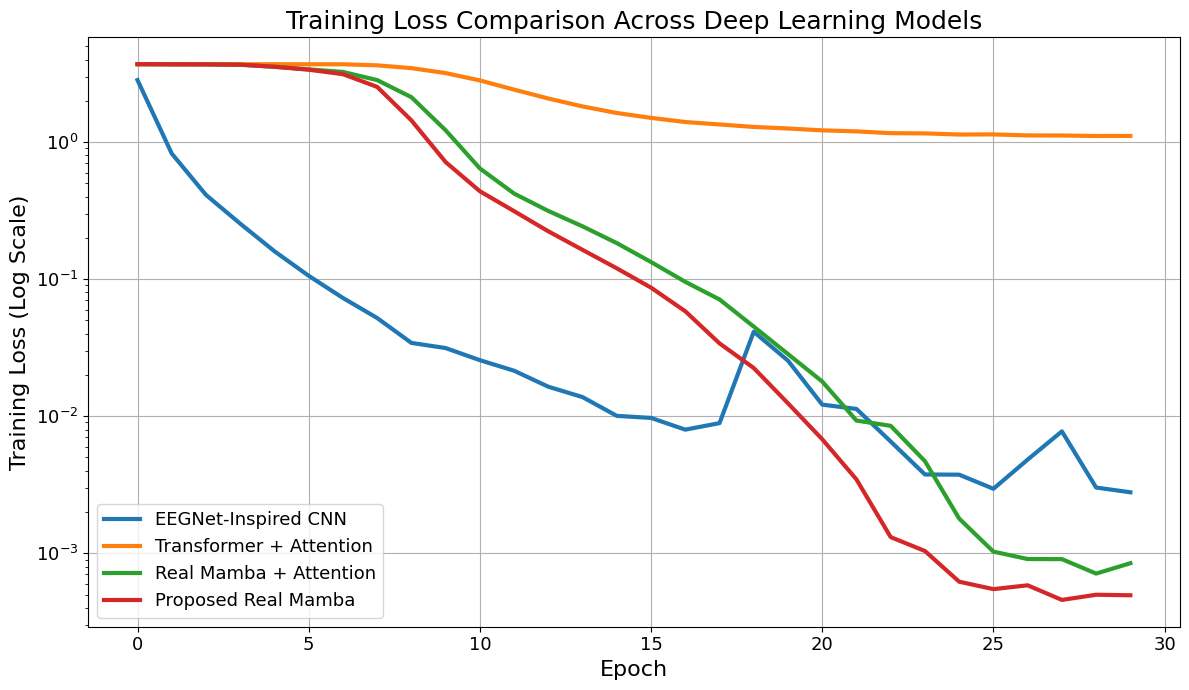

In [62]:
# ============================================================
# CELL 1
# TRAINING LOSS CURVES
# ============================================================

plt.figure(figsize=(12,7))

# ------------------------------------------------------------
# EEGNET
# ------------------------------------------------------------

plt.plot(
    train_losses,
    linewidth=3,
    label='EEGNet-Inspired CNN'
)

# ------------------------------------------------------------
# TRANSFORMER
# ------------------------------------------------------------

plt.plot(
    transformer_losses,
    linewidth=3,
    label='Transformer + Attention'
)

# ------------------------------------------------------------
# REAL MAMBA + ATTENTION
# ------------------------------------------------------------

plt.plot(
    mamba_att_losses,
    linewidth=3,
    label='Real Mamba + Attention'
)

# ------------------------------------------------------------
# PROPOSED REAL MAMBA
# ------------------------------------------------------------

plt.plot(
    mamba_losses,
    linewidth=3,
    label='Proposed Real Mamba'
)

# ------------------------------------------------------------
# LOG SCALE
# ------------------------------------------------------------

plt.yscale('log')

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.xlabel(
    "Epoch",
    fontsize=16
)

plt.ylabel(
    "Training Loss (Log Scale)",
    fontsize=16
)

plt.title(
    "Training Loss Comparison Across Deep Learning Models",
    fontsize=18
)

plt.xticks(fontsize=13)

plt.yticks(fontsize=13)

plt.legend(fontsize=13)

plt.grid(True)

plt.tight_layout()

plt.show()

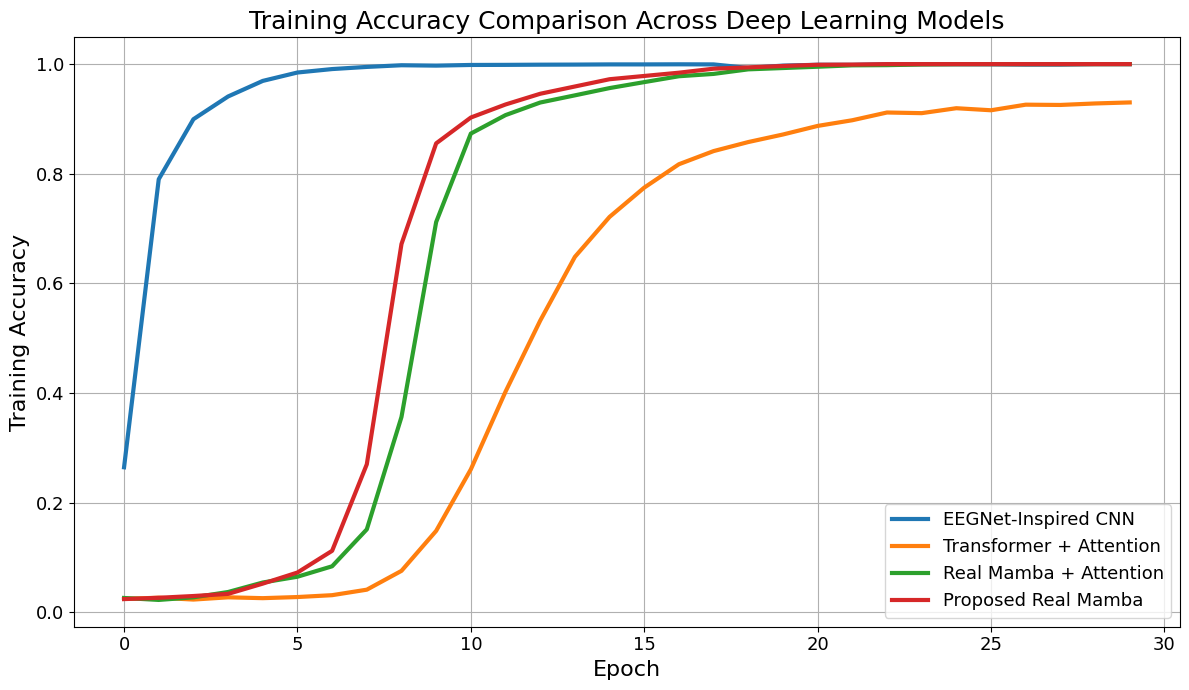

In [64]:
# ============================================================
# CELL 2
# TRAINING ACCURACY CURVES
# ============================================================

plt.figure(figsize=(12,7))

# ------------------------------------------------------------
# EEGNET
# ------------------------------------------------------------

plt.plot(
    train_accuracies,
    linewidth=3,
    label='EEGNet-Inspired CNN'
)

# ------------------------------------------------------------
# TRANSFORMER
# ------------------------------------------------------------

plt.plot(
    transformer_train_accs,
    linewidth=3,
    label='Transformer + Attention'
)

# ------------------------------------------------------------
# REAL MAMBA + ATTENTION
# ------------------------------------------------------------

plt.plot(
    mamba_att_train_accs,
    linewidth=3,
    label='Real Mamba + Attention'
)

# ------------------------------------------------------------
# PROPOSED REAL MAMBA
# ------------------------------------------------------------

plt.plot(
    mamba_train_accs,
    linewidth=3,
    label='Proposed Real Mamba'
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.xlabel(
    "Epoch",
    fontsize=16
)

plt.ylabel(
    "Training Accuracy",
    fontsize=16
)

plt.title(
    "Training Accuracy Comparison Across Deep Learning Models",
    fontsize=18
)

plt.xticks(fontsize=13)

plt.yticks(fontsize=13)

plt.legend(fontsize=13)

plt.grid(True)

plt.tight_layout()

plt.show()

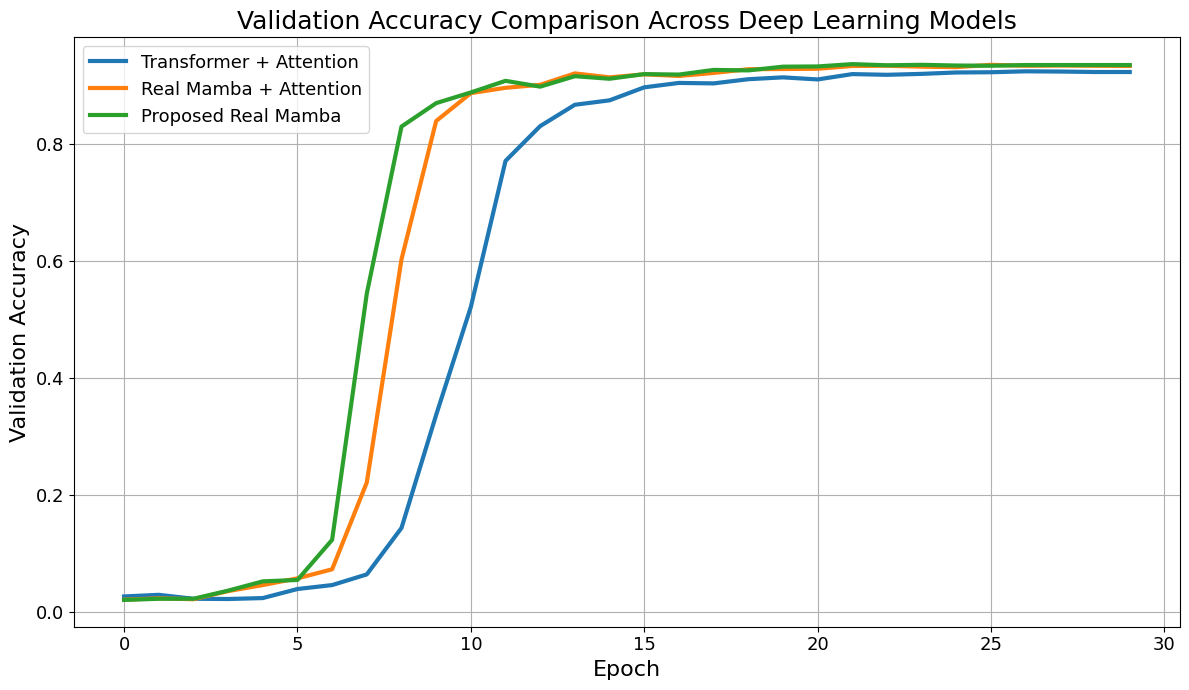

In [65]:
# ============================================================
# CELL 3
# VALIDATION ACCURACY CURVES
# ============================================================

plt.figure(figsize=(12,7))

# ------------------------------------------------------------
# TRANSFORMER
# ------------------------------------------------------------

plt.plot(
    transformer_val_accs,
    linewidth=3,
    label='Transformer + Attention'
)

# ------------------------------------------------------------
# REAL MAMBA + ATTENTION
# ------------------------------------------------------------

plt.plot(
    mamba_att_val_accs,
    linewidth=3,
    label='Real Mamba + Attention'
)

# ------------------------------------------------------------
# PROPOSED REAL MAMBA
# ------------------------------------------------------------

plt.plot(
    mamba_val_accs,
    linewidth=3,
    label='Proposed Real Mamba'
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.xlabel(
    "Epoch",
    fontsize=16
)

plt.ylabel(
    "Validation Accuracy",
    fontsize=16
)

plt.title(
    "Validation Accuracy Comparison Across Deep Learning Models",
    fontsize=18
)

plt.xticks(fontsize=13)

plt.yticks(fontsize=13)

plt.legend(fontsize=13)

plt.grid(True)

plt.tight_layout()

plt.show()

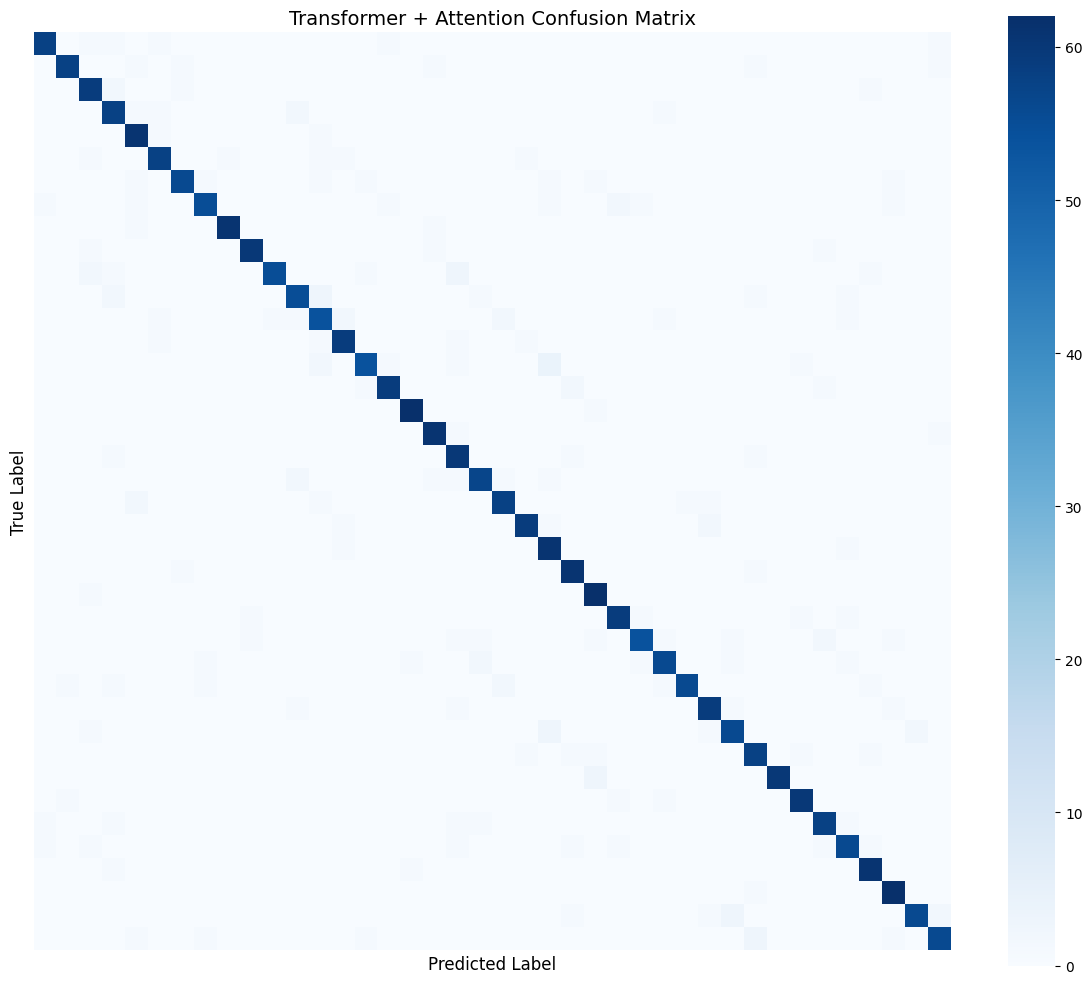

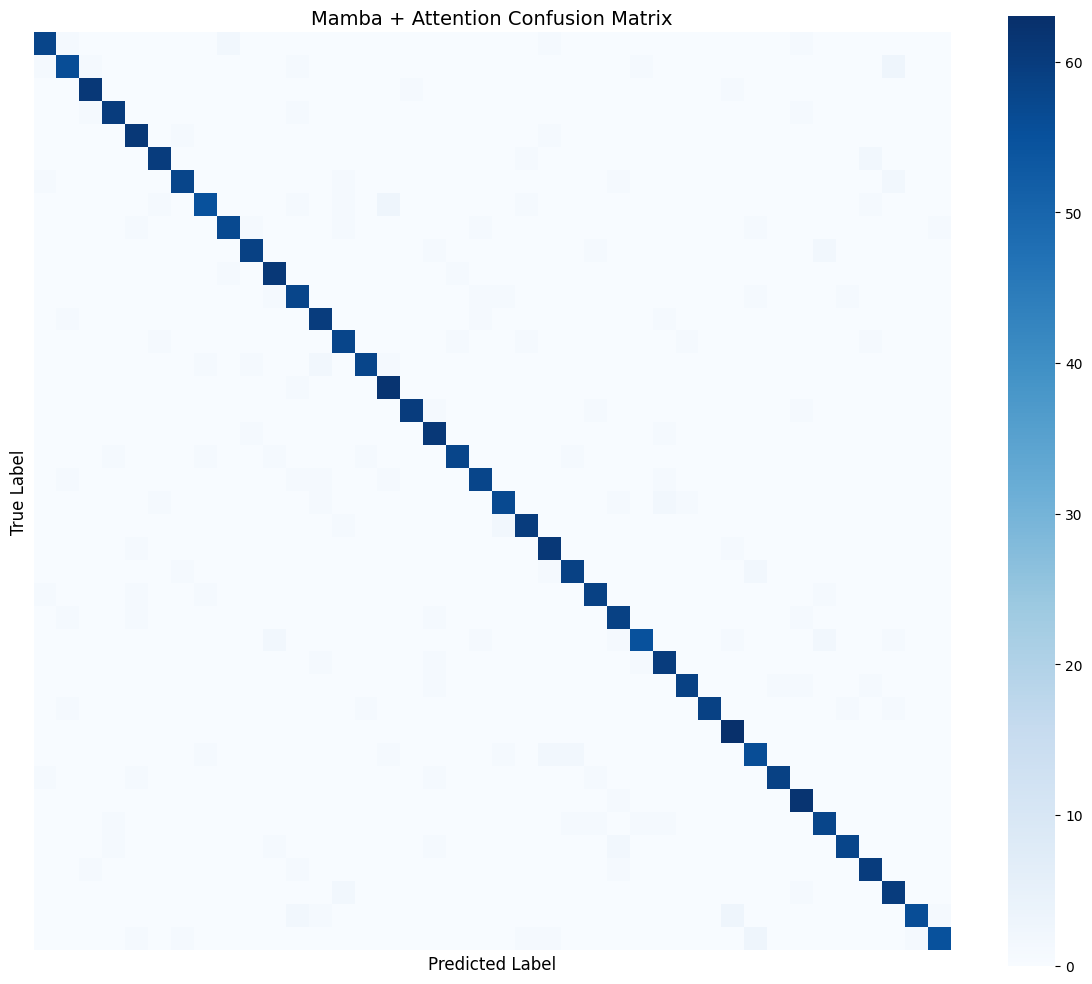

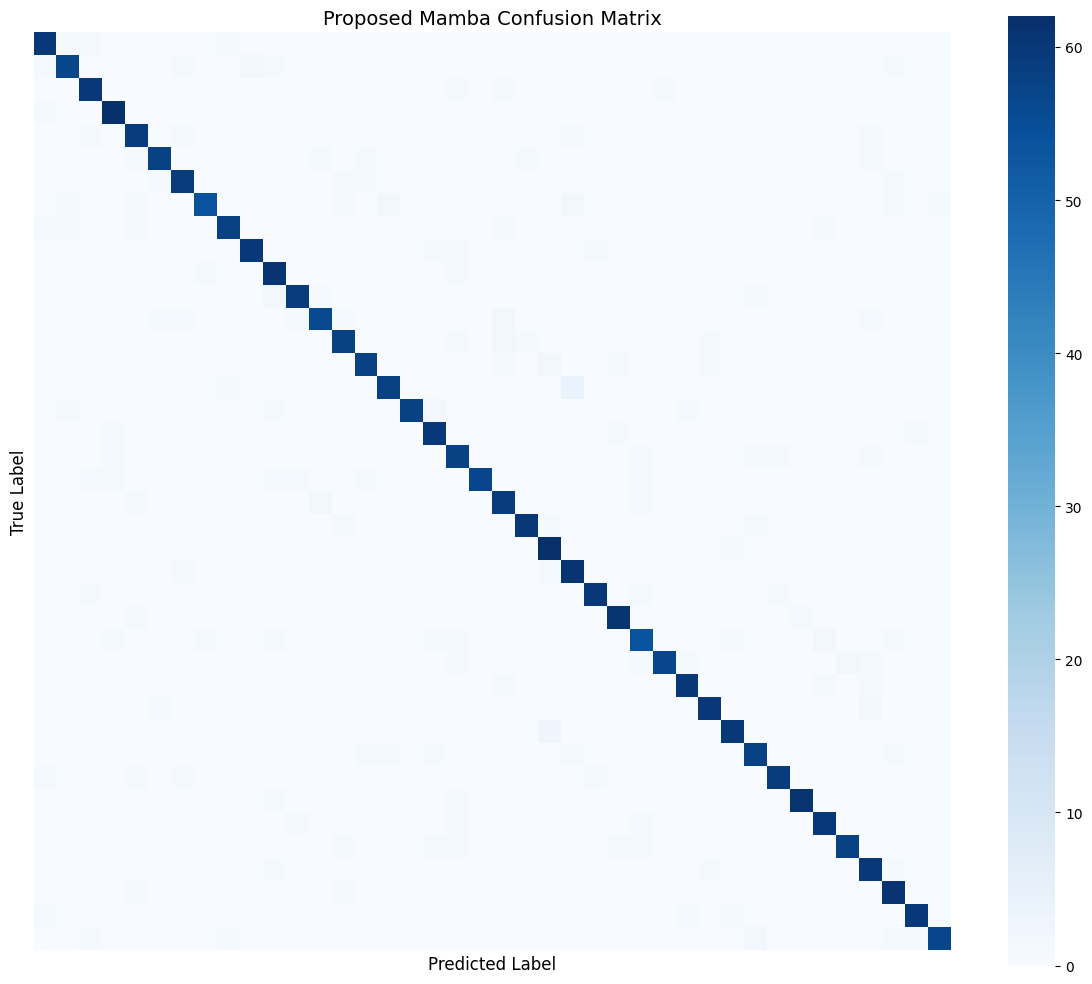

In [66]:
# ============================================================
# CONFUSION MATRIX FUNCTION
# ============================================================

def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        cmap='Blues',
        cbar=True,
        square=True,
        xticklabels=False,
        yticklabels=False
    )

    plt.title(title, fontsize=14)

    plt.xlabel("Predicted Label", fontsize=12)

    plt.ylabel("True Label", fontsize=12)

    plt.tight_layout()

    plt.show()

# ============================================================
# CONFUSION MATRICES
# ============================================================

plot_confusion_matrix(
    transformer_labels,
    transformer_preds,
    "Transformer + Attention Confusion Matrix"
)

plot_confusion_matrix(
    mamba_att_labels,
    mamba_att_preds,
    "Mamba + Attention Confusion Matrix"
)

plot_confusion_matrix(
    mamba_labels,
    mamba_preds,
    "Proposed Mamba Confusion Matrix"
)

In [70]:
# ============================================================
# IMPORTS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc as sklearn_auc
)

# ============================================================
# MULTICLASS ROC FUNCTION
# ============================================================

n_classes = 40

def plot_multiclass_roc(
    y_true_labels,
    y_prob,
    title
):

    # --------------------------------------------------------
    # BINARIZE LABELS
    # --------------------------------------------------------

    y_true_bin = label_binarize(
        y_true_labels,
        classes=np.arange(n_classes)
    )

    # --------------------------------------------------------
    # MICRO-AVERAGE ROC
    # --------------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_true_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = sklearn_auc(fpr, tpr)

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel(
        "False Positive Rate",
        fontsize=12
    )

    plt.ylabel(
        "True Positive Rate",
        fontsize=12
    )

    plt.title(
        title,
        fontsize=14
    )

    plt.legend(fontsize=11)

    plt.grid(True)

    plt.tight_layout()

    plt.show()

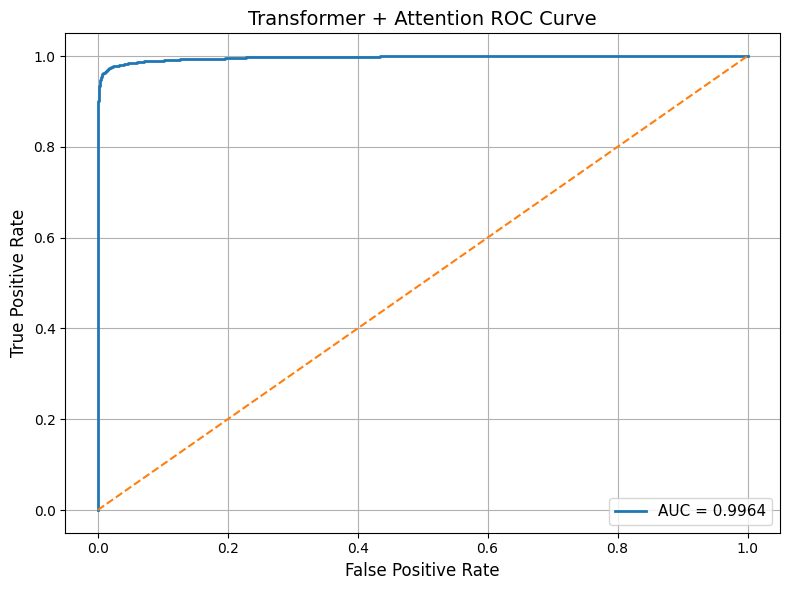

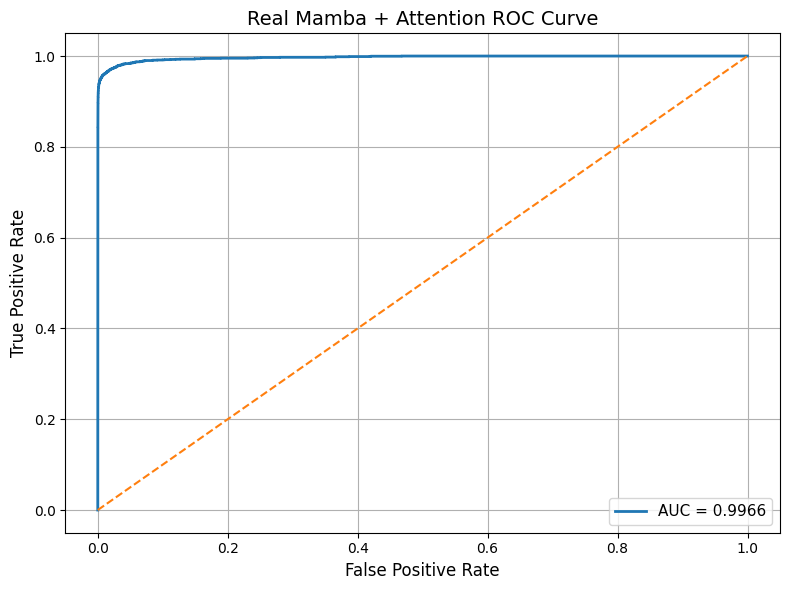

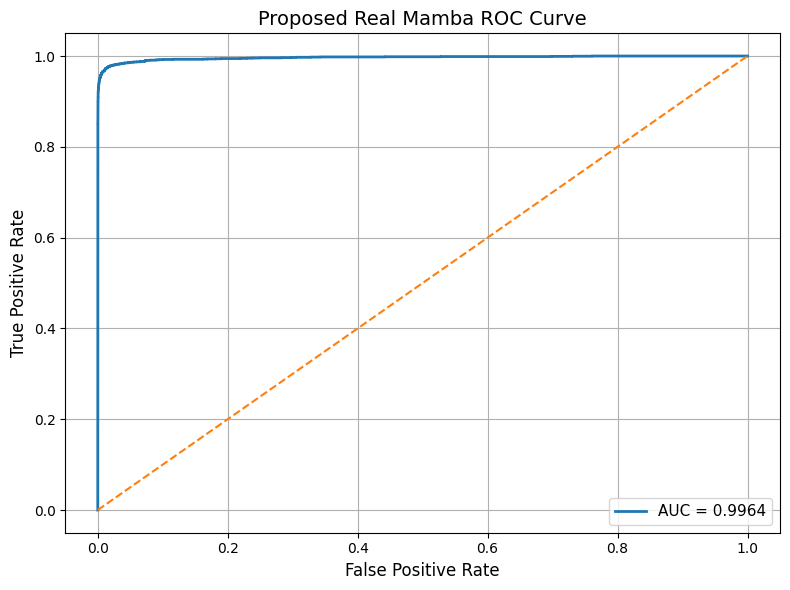

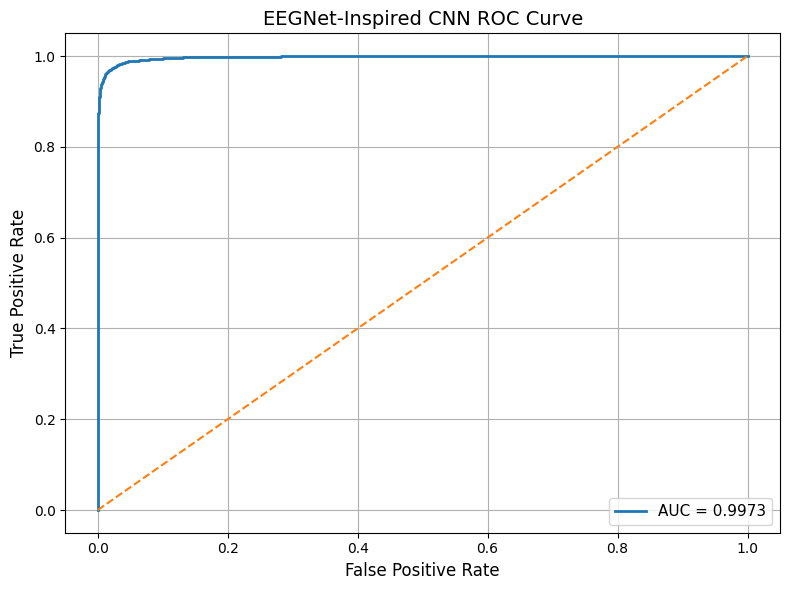

In [71]:
# ============================================================
# ROC CURVES
# ============================================================

plot_multiclass_roc(
    transformer_labels,
    transformer_probs,
    "Transformer + Attention ROC Curve"
)

plot_multiclass_roc(
    mamba_att_labels,
    mamba_att_probs,
    "Real Mamba + Attention ROC Curve"
)

plot_multiclass_roc(
    mamba_labels,
    mamba_probs,
    "Proposed Real Mamba ROC Curve"
)

plot_multiclass_roc(
    eegnet_labels,
    eegnet_probs,
    "EEGNet-Inspired CNN ROC Curve"
)

In [76]:
# ============================================================
# REAL 10-FOLD CV ARRAYS
# ============================================================

# ------------------------------------------------------------
# EEGNET
# ------------------------------------------------------------

eegnet_fold_accs = [
    0.8988,
    0.9095,
    0.9190,
    0.9179,
    0.9143,
    0.9214,
    0.9095,
    0.9071,
    0.9143,
    0.9155
]

# ------------------------------------------------------------
# TRANSFORMER + ATTENTION
# ------------------------------------------------------------

transformer_fold_accs = [
    0.8167,
    0.6595,
    0.8262,
    0.4857,
    0.8250,
    0.8357,
    0.8310,
    0.8321,
    0.8262,
    0.8405
]

# ------------------------------------------------------------
# REAL MAMBA + ATTENTION
# ------------------------------------------------------------

mamba_att_fold_accs = [
    0.9310,
    0.9345,
    0.9512,
    0.9417,
    0.9381,
    0.9464,
    0.9381,
    0.9524,
    0.9417,
    0.9298
]

# ------------------------------------------------------------
# PROPOSED REAL MAMBA
# ------------------------------------------------------------

mamba_fold_accs = [
    0.9333,
    0.9524,
    0.9536,
    0.9381,
    0.9381,
    0.9512,
    0.9476,
    0.9548,
    0.9464,
    0.9357
]

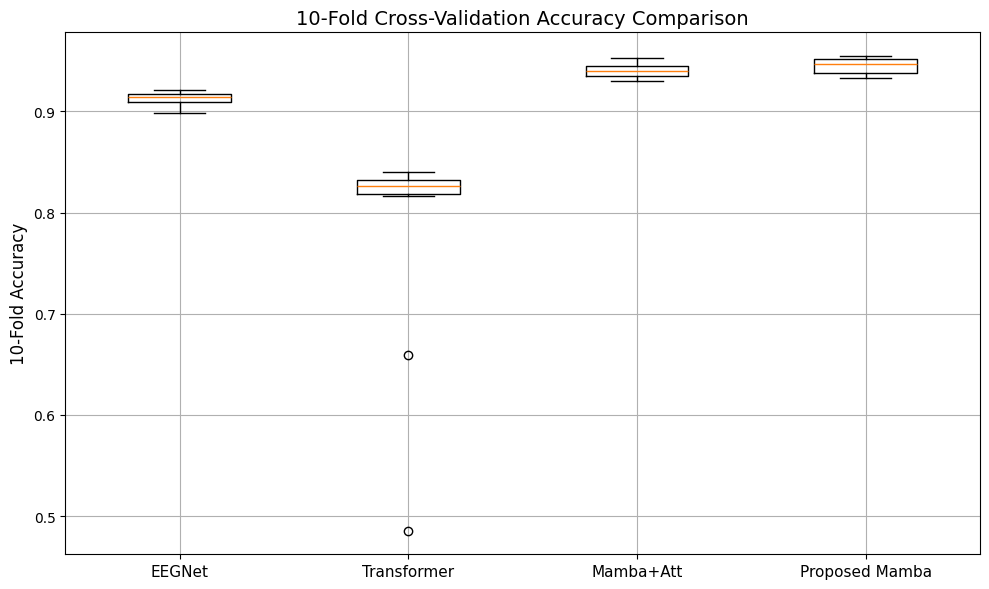

In [77]:
# ============================================================
# 10-FOLD CV BOXPLOT
# ============================================================

plt.figure(figsize=(10,6))

plt.boxplot([
    eegnet_fold_accs,
    transformer_fold_accs,
    mamba_att_fold_accs,
    mamba_fold_accs
])

plt.xticks(
    [1,2,3,4],
    [
        "EEGNet",
        "Transformer",
        "Mamba+Att",
        "Proposed Mamba"
    ],
    fontsize=11
)

plt.ylabel(
    "10-Fold Accuracy",
    fontsize=12
)

plt.title(
    "10-Fold Cross-Validation Accuracy Comparison",
    fontsize=14
)

plt.grid(True)

plt.tight_layout()

plt.show()

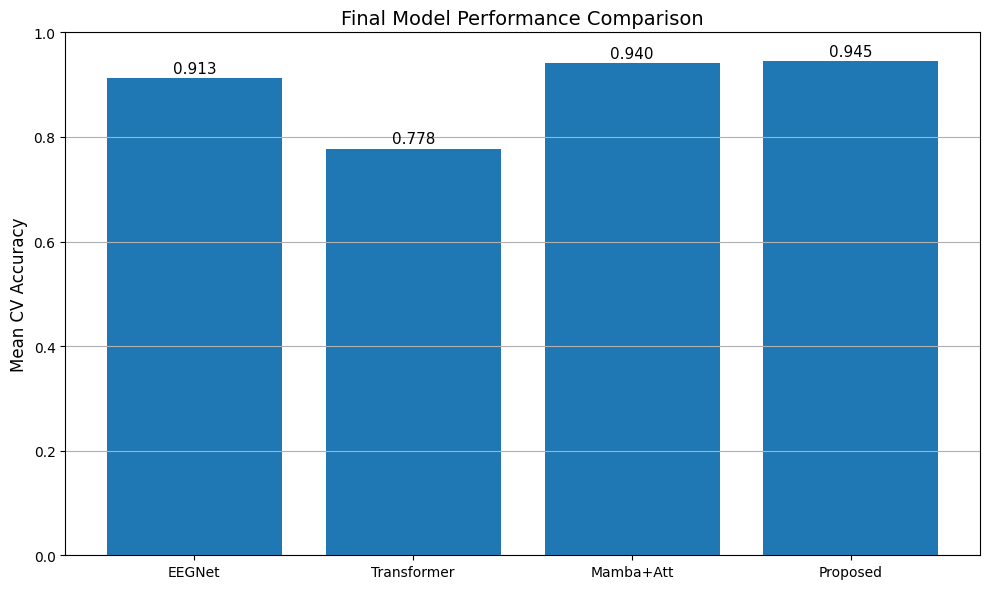

In [78]:
# ============================================================
# FINAL MEAN ACCURACY BARPLOT
# ============================================================

model_names = [
    "EEGNet",
    "Transformer",
    "Mamba+Att",
    "Proposed"
]

model_means = [
    np.mean(eegnet_fold_accs),
    np.mean(transformer_fold_accs),
    np.mean(mamba_att_fold_accs),
    np.mean(mamba_fold_accs)
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    model_names,
    model_means
)

plt.ylabel(
    "Mean CV Accuracy",
    fontsize=12
)

plt.title(
    "Final Model Performance Comparison",
    fontsize=14
)

plt.ylim(0,1)

plt.grid(axis='y')

for bar, value in zip(bars, model_means):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.3f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [79]:
# ============================================================
# STATISTICAL SIGNIFICANCE TESTING
# USING 10-FOLD CV RESULTS
# ============================================================

from scipy.stats import ttest_rel, wilcoxon
import numpy as np

# ============================================================
# FUNCTION
# ============================================================

def run_statistical_test(
    model1_scores,
    model2_scores,
    model1_name,
    model2_name
):

    print("\n================================================")
    print(f"{model1_name} vs {model2_name}")
    print("================================================")

    model1_scores = np.array(model1_scores)
    model2_scores = np.array(model2_scores)

    # --------------------------------------------------------
    # PAIRED T-TEST
    # --------------------------------------------------------

    t_stat, t_p = ttest_rel(
        model1_scores,
        model2_scores
    )

    # --------------------------------------------------------
    # WILCOXON SIGNED-RANK TEST
    # --------------------------------------------------------

    w_stat, w_p = wilcoxon(
        model1_scores,
        model2_scores
    )

    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    print(f"Model 1 Mean: {model1_scores.mean():.4f}")
    print(f"Model 2 Mean: {model2_scores.mean():.4f}")

    print(f"\nPaired t-test p-value : {t_p:.6f}")
    print(f"Wilcoxon p-value      : {w_p:.6f}")

    if t_p < 0.05:
        print("Paired t-test: Significant")
    else:
        print("Paired t-test: Not significant")

    if w_p < 0.05:
        print("Wilcoxon: Significant")
    else:
        print("Wilcoxon: Not significant")

In [80]:
run_statistical_test(
    transformer_fold_accs,
    mamba_fold_accs,
    "Transformer",
    "Proposed Mamba"
)

run_statistical_test(
    mamba_att_fold_accs,
    mamba_fold_accs,
    "Mamba + Attention",
    "Proposed Mamba"
)

run_statistical_test(
    eegnet_fold_accs,
    mamba_fold_accs,
    "EEGNet",
    "Proposed Mamba"
)


Transformer vs Proposed Mamba
Model 1 Mean: 0.7779
Model 2 Mean: 0.9451

Paired t-test p-value : 0.001284
Wilcoxon p-value      : 0.001953
Paired t-test: Significant
Wilcoxon: Significant

Mamba + Attention vs Proposed Mamba
Model 1 Mean: 0.9405
Model 2 Mean: 0.9451

Paired t-test p-value : 0.033258
Wilcoxon p-value      : 0.027344
Paired t-test: Significant
Wilcoxon: Significant

EEGNet vs Proposed Mamba
Model 1 Mean: 0.9127
Model 2 Mean: 0.9451

Paired t-test p-value : 0.000001
Wilcoxon p-value      : 0.001953
Paired t-test: Significant
Wilcoxon: Significant


In [86]:
# ============================================================
# MODEL COMPLEXITY ANALYSIS
# FULLY MODIFIED VERSION
# ============================================================

# ============================================================
# INSTALL THOP
# ============================================================

# RUN ONLY ONCE
# !pip install thop

# ============================================================
# IMPORTS
# ============================================================

import torch

import pandas as pd

from thop import profile

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# ============================================================
# COMPLEXITY FUNCTION
# ============================================================

def compute_complexity(
    model,
    input_shape
):

    # --------------------------------------------------------
    # MODEL TO DEVICE
    # --------------------------------------------------------

    model = model.to(device)

    model.eval()

    # --------------------------------------------------------
    # DUMMY INPUT
    # --------------------------------------------------------

    dummy_input = torch.randn(
        input_shape
    ).to(device)

    # --------------------------------------------------------
    # THOP PROFILE
    # --------------------------------------------------------

    flops, params = profile(
        model,
        inputs=(dummy_input,),
        verbose=False
    )

    # --------------------------------------------------------
    # CONVERT TO MILLIONS
    # --------------------------------------------------------

    params_m = params / 1e6

    flops_m = flops / 1e6

    # --------------------------------------------------------
    # RETURN
    # --------------------------------------------------------

    return {

        "Parameters (M)": round(
            params_m,
            3
        ),

        "FLOPs (M)": round(
            flops_m,
            3
        )
    }

# ============================================================
# EEGNET
# ============================================================

eegnet_results = compute_complexity(

    model=eegnet,

    # EEGNET INPUT:
    # (batch, channels, sequence)

    input_shape=(1, 128, 295)

)

# ============================================================
# TRANSFORMER + ATTENTION
# ============================================================

transformer_results = compute_complexity(

    model=model_t,

    # TRANSFORMER INPUT:
    # (batch, sequence, features)

    input_shape=(1, 265, 64)

)

# ============================================================
# REAL MAMBA + ATTENTION
# ============================================================

mamba_att_results = compute_complexity(

    model=mamba_attention_model,

    input_shape=(1, 265, 64)

)

# ============================================================
# PROPOSED REAL MAMBA
# ============================================================

mamba_results = compute_complexity(

    model=proposed_mamba,

    input_shape=(1, 265, 64)

)

# ============================================================
# CREATE TABLE
# ============================================================

complexity_df = pd.DataFrame({

    "Model": [

        "EEGNet",

        "Transformer + Attention",

        "Real Mamba + Attention",

        "Proposed Real Mamba"
    ],

    "Parameters (M)": [

        eegnet_results["Parameters (M)"],

        transformer_results["Parameters (M)"],

        mamba_att_results["Parameters (M)"],

        mamba_results["Parameters (M)"]
    ],

    "FLOPs (M)": [

        eegnet_results["FLOPs (M)"],

        transformer_results["FLOPs (M)"],

        mamba_att_results["FLOPs (M)"],

        mamba_results["FLOPs (M)"]
    ]
})

# ============================================================
# DISPLAY
# ============================================================

print("\n================================================")

print("MODEL COMPLEXITY ANALYSIS")

print("================================================\n")

display(complexity_df)


MODEL COMPLEXITY ANALYSIS



,Model,Parameters (M),FLOPs (M)
0,EEGNet,2.501,25.491
1,Transformer + Attention,35.818,177.471
2,Real Mamba + Attention,0.061,4.674
3,Proposed Real Mamba,0.061,4.674


In [87]:
# ============================================================
# INFERENCE TIME ANALYSIS
# ============================================================

import time

import numpy as np

import pandas as pd

import torch

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# ============================================================
# INFERENCE FUNCTION
# ============================================================

def measure_inference_time(
    model,
    input_shape,
    repetitions=200
):

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model.eval()

    model.to(device)

    # --------------------------------------------------------
    # DUMMY INPUT
    # --------------------------------------------------------

    dummy_input = torch.randn(
        input_shape
    ).to(device)

    # --------------------------------------------------------
    # GPU WARMUP
    # --------------------------------------------------------

    with torch.no_grad():

        for _ in range(20):

            _ = model(dummy_input)

    # --------------------------------------------------------
    # TIMING
    # --------------------------------------------------------

    timings = []

    with torch.no_grad():

        for _ in range(repetitions):

            if device.type == "cuda":

                torch.cuda.synchronize()

            start = time.time()

            _ = model(dummy_input)

            if device.type == "cuda":

                torch.cuda.synchronize()

            end = time.time()

            timings.append(end - start)

    # --------------------------------------------------------
    # MILLISECONDS
    # --------------------------------------------------------

    mean_time_ms = np.mean(
        timings
    ) * 1000

    std_time_ms = np.std(
        timings
    ) * 1000

    return round(mean_time_ms, 3), round(std_time_ms, 3)

# ============================================================
# EEGNET
# ============================================================

eegnet_time = measure_inference_time(

    eegnet,

    input_shape=(1, 128, 295)

)

# ============================================================
# TRANSFORMER
# ============================================================

transformer_time = measure_inference_time(

    model_t,

    input_shape=(1, 265, 64)

)

# ============================================================
# REAL MAMBA + ATTENTION
# ============================================================

mamba_att_time = measure_inference_time(

    mamba_attention_model,

    input_shape=(1, 265, 64)

)

# ============================================================
# PROPOSED REAL MAMBA
# ============================================================

mamba_time = measure_inference_time(

    proposed_mamba,

    input_shape=(1, 265, 64)

)

# ============================================================
# CREATE TABLE
# ============================================================

inference_df = pd.DataFrame({

    "Model": [

        "EEGNet",

        "Transformer + Attention",

        "Real Mamba + Attention",

        "Proposed Real Mamba"
    ],

    "Inference Time (ms)": [

        eegnet_time[0],

        transformer_time[0],

        mamba_att_time[0],

        mamba_time[0]
    ],

    "Std (ms)": [

        eegnet_time[1],

        transformer_time[1],

        mamba_att_time[1],

        mamba_time[1]
    ]
})

# ============================================================
# DISPLAY
# ============================================================

print("\n================================================")

print("INFERENCE TIME ANALYSIS")

print("================================================\n")

display(inference_df)


INFERENCE TIME ANALYSIS



,Model,Inference Time (ms),Std (ms)
0,EEGNet,0.647,0.065
1,Transformer + Attention,2.121,0.162
2,Real Mamba + Attention,2.155,0.105
3,Proposed Real Mamba,1.924,0.123


In [88]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.2 MB/s eta 0:00:00


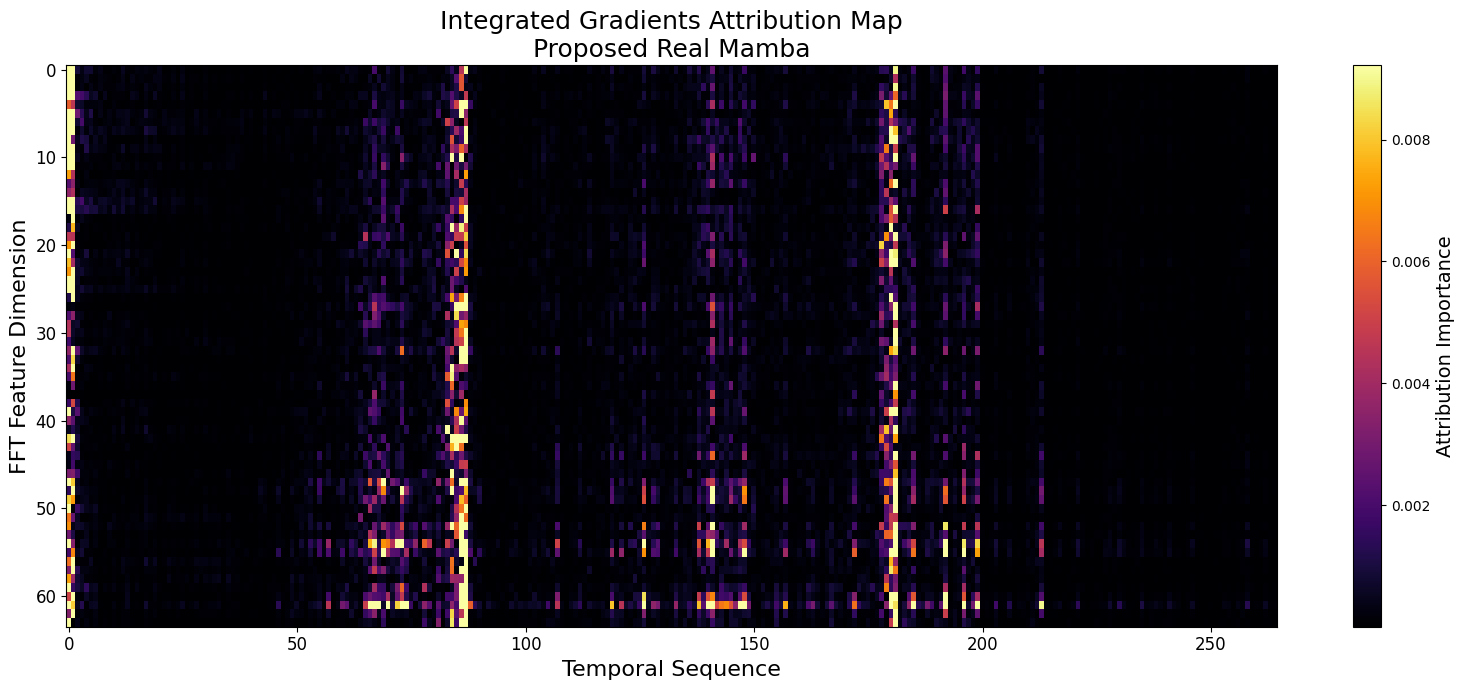

In [96]:
# ============================================================
# IMPROVED ATTRIBUTION VISUALIZATION
# ============================================================

import numpy as np

import matplotlib.pyplot as plt

# ============================================================
# PERCENTILE CONTRAST ENHANCEMENT
# ============================================================

vmax = np.percentile(attr, 99)

vmin = np.percentile(attr, 5)

# ============================================================
# FIGURE
# ============================================================

plt.figure(figsize=(16,7))

plt.imshow(

    attr.T,

    aspect='auto',

    cmap='inferno',

    vmin=vmin,

    vmax=vmax

)

# ============================================================
# COLORBAR
# ============================================================

cbar = plt.colorbar()

cbar.set_label(
    "Attribution Importance",
    fontsize=14
)

# ============================================================
# LABELS
# ============================================================

plt.xlabel(
    "Temporal Sequence",
    fontsize=16
)

plt.ylabel(
    "FFT Feature Dimension",
    fontsize=16
)

plt.title(
    "Integrated Gradients Attribution Map\nProposed Real Mamba",
    fontsize=18
)

plt.xticks(fontsize=12)

plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

In [14]:
# ============================================================
# LOSO TRANSFORMER
# ============================================================
import torch
import torch.nn as nn
class LOSOTransformer(nn.Module):

    def __init__(
        self,
        n_freqs,
        n_chans,
        n_classes
    ):

        super().__init__()

        d_model = 128

        # ----------------------------------------------------
        # EMBEDDING
        # ----------------------------------------------------

        self.embed = nn.Sequential(

            nn.Linear(
                n_chans,
                d_model
            ),

            nn.LayerNorm(d_model)
        )

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.positional_encoding = nn.Parameter(

            torch.randn(
                1,
                n_freqs,
                d_model
            ) * 0.02
        )

        # ----------------------------------------------------
        # TRANSFORMER
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(

            d_model=d_model,

            nhead=4,

            dim_feedforward=256,

            dropout=0.1,

            batch_first=True,

            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=2
        )

        # ----------------------------------------------------
        # ATTENTION POOLING
        # ----------------------------------------------------

        self.attention_pool = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.Tanh(),

            nn.Linear(64, 1)
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Linear(d_model, 256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, n_classes)
        )

    def forward(self, x):

        x = self.embed(x)

        x = x + self.positional_encoding

        x = self.transformer(x)

        # ----------------------------------------------------
        # ATTENTION POOLING
        # ----------------------------------------------------

        attn_weights = self.attention_pool(x)

        attn_weights = torch.softmax(
            attn_weights,
            dim=1
        )

        x = (x * attn_weights).sum(dim=1)

        x = self.classifier(x)

        return x

In [20]:
# ============================================================
# LOSO MAMBA + ATTENTION
# ============================================================
from mamba_ssm import Mamba
class LOSOMambaAttention(nn.Module):

    def __init__(
        self,
        input_dim,
        n_freqs,
        num_classes=40,
        d_model=64
    ):

        super().__init__()

        self.embedding = nn.Linear(
            input_dim,
            d_model
        )

        self.positional_encoding = nn.Parameter(

            torch.randn(
                1,
                n_freqs,
                d_model
            ) * 0.02
        )

        self.mamba1 = Mamba(

            d_model=d_model,

            d_state=16,

            d_conv=4,

            expand=2
        )

        self.mamba2 = Mamba(

            d_model=d_model,

            d_state=16,

            d_conv=4,

            expand=2
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.norm2 = nn.LayerNorm(d_model)

        # ----------------------------------------------------
        # SMALLER ATTENTION
        # ----------------------------------------------------

        self.attention = nn.MultiheadAttention(

            embed_dim=d_model,

            num_heads=4,

            batch_first=True
        )

        # ----------------------------------------------------
        # ATTENTION POOLING
        # ----------------------------------------------------

        self.attention_pool = nn.Sequential(

            nn.Linear(d_model, 32),

            nn.Tanh(),

            nn.Linear(32, 1)
        )

        self.classifier = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Linear(d_model, 128),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.embedding(x)

        x = x + self.positional_encoding

        x = self.norm1(
            self.mamba1(x)
        )

        x = self.norm2(
            self.mamba2(x)
        )

        attn_output, _ = self.attention(
            x,
            x,
            x
        )

        x = x + attn_output

        attn_weights = self.attention_pool(x)

        attn_weights = torch.softmax(
            attn_weights,
            dim=1
        )

        x = (x * attn_weights).sum(dim=1)

        x = self.classifier(x)

        return x

In [21]:
# ============================================================
# LOSO PROPOSED MAMBA
# ============================================================

class LOSOProposedMamba(nn.Module):

    def __init__(
        self,
        input_dim,
        n_freqs,
        num_classes=40,
        d_model=64
    ):

        super().__init__()

        self.embedding = nn.Linear(
            input_dim,
            d_model
        )

        self.positional_encoding = nn.Parameter(

            torch.randn(
                1,
                n_freqs,
                d_model
            ) * 0.02
        )

        self.mamba1 = Mamba(

            d_model=d_model,

            d_state=16,

            d_conv=4,

            expand=2
        )

        self.mamba2 = Mamba(

            d_model=d_model,

            d_state=16,

            d_conv=4,

            expand=2
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.norm2 = nn.LayerNorm(d_model)

        # ----------------------------------------------------
        # ATTENTION POOLING
        # ----------------------------------------------------

        self.attention_pool = nn.Sequential(

            nn.Linear(d_model, 32),

            nn.Tanh(),

            nn.Linear(32, 1)
        )

        self.classifier = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Linear(d_model, 128),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.embedding(x)

        x = x + self.positional_encoding

        x = self.norm1(
            self.mamba1(x)
        )

        x = self.norm2(
            self.mamba2(x)
        )

        attn_weights = self.attention_pool(x)

        attn_weights = torch.softmax(
            attn_weights,
            dim=1
        )

        x = (x * attn_weights).sum(dim=1)

        x = self.classifier(x)

        return x

In [17]:
# ============================================================
# FINAL LOSO FUNCTION
# SUBJECT-WISE SAFE NORMALIZATION
# ============================================================

import numpy as np
import torch

from torch.utils.data import (
    DataLoader,
    Dataset
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print(f"Using device: {device}")

# ============================================================
# GENERIC DATASET
# ============================================================

class GenericDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

# ============================================================
# LOSO FUNCTION
# ============================================================

def run_subjectwise_evaluation(

    model_class,

    model_name,

    X_data,

    y_data,

    subjects,

    model_kwargs=None,

    epochs=30,

    batch_size=64,

    learning_rate=1e-4

):

    if model_kwargs is None:

        model_kwargs = {}

    print("\n================================================")

    print(f"SUBJECT-WISE EVALUATION: {model_name}")

    print("================================================")

    unique_subjects = np.unique(subjects)

    subject_accuracies = []

    subject_precisions = []

    subject_recalls = []

    subject_f1s = []

    # ========================================================
    # LOSO LOOP
    # ========================================================

    for subject in unique_subjects:

        print(f"\nTesting Subject S{subject}")

        # ----------------------------------------------------
        # SPLIT
        # ----------------------------------------------------

        train_mask = subjects != subject

        test_mask = subjects == subject

        X_train = X_data[train_mask]

        y_train = y_data[train_mask]

        X_test = X_data[test_mask]

        y_test = y_data[test_mask]

        # ====================================================
        # SUBJECT-WISE SAFE NORMALIZATION
        # ====================================================

        scaler = StandardScaler()

        X_train_reshaped = X_train.reshape(
            -1,
            X_train.shape[-1]
        )

        X_test_reshaped = X_test.reshape(
            -1,
            X_test.shape[-1]
        )

        # ----------------------------------------------------
        # FIT ONLY ON TRAIN
        # ----------------------------------------------------

        X_train_scaled = scaler.fit_transform(
            X_train_reshaped
        )

        # ----------------------------------------------------
        # TRANSFORM TEST
        # ----------------------------------------------------

        X_test_scaled = scaler.transform(
            X_test_reshaped
        )

        # ----------------------------------------------------
        # RESHAPE BACK
        # ----------------------------------------------------

        X_train = X_train_scaled.reshape(
            X_train.shape
        ).astype(np.float32)

        X_test = X_test_scaled.reshape(
            X_test.shape
        ).astype(np.float32)

        # ----------------------------------------------------
        # DATASETS
        # ----------------------------------------------------

        train_dataset = GenericDataset(
            X_train,
            y_train
        )

        test_dataset = GenericDataset(
            X_test,
            y_test
        )

        # ----------------------------------------------------
        # DATALOADERS
        # ----------------------------------------------------

        train_loader = DataLoader(

            train_dataset,

            batch_size=batch_size,

            shuffle=True
        )

        test_loader = DataLoader(

            test_dataset,

            batch_size=batch_size,

            shuffle=False
        )

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        model = model_class(
            **model_kwargs
        ).to(device)

        # ----------------------------------------------------
        # OPTIMIZER
        # ----------------------------------------------------

        optimizer = torch.optim.AdamW(

            model.parameters(),

            lr=learning_rate,

            weight_decay=1e-4
        )

        # ----------------------------------------------------
        # SCHEDULER
        # ----------------------------------------------------

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=epochs
        )

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        criterion = torch.nn.CrossEntropyLoss(
            label_smoothing=0.1
)
        # ====================================================
        # TRAINING
        # ====================================================

        for epoch in range(epochs):

            model.train()

            running_loss = 0

            correct = 0

            total = 0

            for batch_x, batch_y in train_loader:

                batch_x = batch_x.to(device)

                batch_y = batch_y.to(device)

                optimizer.zero_grad()

                outputs = model(batch_x)

                loss = criterion(
                    outputs,
                    batch_y
                )

                loss.backward()

                # ------------------------------------------------
                # GRADIENT CLIPPING
                # ------------------------------------------------

                torch.nn.utils.clip_grad_norm_(

                    model.parameters(),

                    1.0
                )

                optimizer.step()

                running_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (
                    preds == batch_y
                ).sum().item()

                total += batch_y.size(0)

            scheduler.step()

            train_acc = correct / total

            # ------------------------------------------------
            # PRINT
            # ------------------------------------------------

            if epoch == 0 or epoch == epochs - 1:

                print(
                    f"Epoch {epoch+1}/{epochs} "
                    f"Loss: {running_loss/len(train_loader):.4f} "
                    f"Train Acc: {train_acc:.4f}"
                )

        # ====================================================
        # EVALUATION
        # ====================================================

        model.eval()

        all_preds = []

        all_labels = []

        with torch.no_grad():

            for batch_x, batch_y in test_loader:

                batch_x = batch_x.to(device)

                outputs = model(batch_x)

                preds = outputs.argmax(
                    dim=1
                ).cpu().numpy()

                all_preds.extend(preds)

                all_labels.extend(
                    batch_y.numpy()
                )

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        acc = accuracy_score(
            all_labels,
            all_preds
        )

        precision = precision_score(
            all_labels,
            all_preds,
            average='macro',
            zero_division=0
        )

        recall = recall_score(
            all_labels,
            all_preds,
            average='macro',
            zero_division=0
        )

        f1 = f1_score(
            all_labels,
            all_preds,
            average='macro',
            zero_division=0
        )

        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        subject_accuracies.append(acc)

        subject_precisions.append(precision)

        subject_recalls.append(recall)

        subject_f1s.append(f1)

        # ----------------------------------------------------
        # RESULTS
        # ----------------------------------------------------

        print(f"Accuracy : {acc:.4f}")

        print(f"Precision: {precision:.4f}")

        print(f"Recall   : {recall:.4f}")

        print(f"F1 Score : {f1:.4f}")

    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print("\n================================================")

    print(f"{model_name} FINAL SUBJECT-WISE RESULTS")

    print("================================================")

    print(
        f"Mean Accuracy : "
        f"{np.mean(subject_accuracies):.4f} ± "
        f"{np.std(subject_accuracies):.4f}"
    )

    print(
        f"Mean Precision: "
        f"{np.mean(subject_precisions):.4f}"
    )

    print(
        f"Mean Recall   : "
        f"{np.mean(subject_recalls):.4f}"
    )

    print(
        f"Mean F1 Score : "
        f"{np.mean(subject_f1s):.4f}"
    )

    return {

        "accuracy_mean": np.mean(subject_accuracies),

        "accuracy_std": np.std(subject_accuracies),

        "precision": np.mean(subject_precisions),

        "recall": np.mean(subject_recalls),

        "f1": np.mean(subject_f1s)

    }

Using device: cuda


In [15]:
eegnet_subjectwise_results = run_subjectwise_evaluation(

    model_class=EEGNet,

    model_name="EEGNet",

    X_data=X_deep,

    y_data=y,

    subjects=subjects,

    model_kwargs={

        "num_classes": 40

    },

    epochs=10,

    batch_size=64,

    learning_rate=1e-3,

    eegnet_mode=True
)


SUBJECT-WISE EVALUATION: EEGNet

Testing Subject S1
Epoch 1/10 Loss: 1.9327 Train Acc: 0.4801
Epoch 2/10 Loss: 0.5902 Train Acc: 0.8397
Epoch 3/10 Loss: 0.3643 Train Acc: 0.8940
Epoch 4/10 Loss: 0.2227 Train Acc: 0.9343
Epoch 5/10 Loss: 0.1719 Train Acc: 0.9501
Epoch 6/10 Loss: 0.1233 Train Acc: 0.9614
Epoch 7/10 Loss: 0.0897 Train Acc: 0.9722
Epoch 8/10 Loss: 0.0744 Train Acc: 0.9778
Epoch 9/10 Loss: 0.0657 Train Acc: 0.9798
Epoch 10/10 Loss: 0.0513 Train Acc: 0.9839
Accuracy : 0.8500
Precision: 0.8968
Recall   : 0.8500
F1 Score : 0.8582

Testing Subject S2
Epoch 1/10 Loss: 2.0973 Train Acc: 0.4414
Epoch 2/10 Loss: 0.6208 Train Acc: 0.8268
Epoch 3/10 Loss: 0.3933 Train Acc: 0.8881
Epoch 4/10 Loss: 0.2617 Train Acc: 0.9234
Epoch 5/10 Loss: 0.1831 Train Acc: 0.9442
Epoch 6/10 Loss: 0.1293 Train Acc: 0.9602
Epoch 7/10 Loss: 0.0945 Train Acc: 0.9702
Epoch 8/10 Loss: 0.0702 Train Acc: 0.9782
Epoch 9/10 Loss: 0.0615 Train Acc: 0.9806
Epoch 10/10 Loss: 0.0540 Train Acc: 0.9828
Accuracy : 0.

In [18]:
transformer_subjectwise_results = run_subjectwise_evaluation(

    model_class=LOSOTransformer,

    model_name="Transformer + Attention",

    X_data=X_deep,

    y_data=y,

    subjects=subjects,

    model_kwargs={

        "n_freqs": X_deep.shape[1],

        "n_chans": X_deep.shape[2],

        "n_classes": 40
    },

    epochs=30,

    batch_size=64,

    learning_rate=1e-4
)


SUBJECT-WISE EVALUATION: Transformer + Attention

Testing Subject S1
Epoch 1/30 Loss: 3.7023 Train Acc: 0.0256
Epoch 30/30 Loss: 2.8041 Train Acc: 0.2102
Accuracy : 0.1792
Precision: 0.1806
Recall   : 0.1792
F1 Score : 0.1652

Testing Subject S2
Epoch 1/30 Loss: 3.7039 Train Acc: 0.0233
Epoch 30/30 Loss: 2.8731 Train Acc: 0.1843
Accuracy : 0.1375
Precision: 0.1439
Recall   : 0.1375
F1 Score : 0.1090

Testing Subject S3
Epoch 1/30 Loss: 3.7027 Train Acc: 0.0244
Epoch 30/30 Loss: 2.8623 Train Acc: 0.1887
Accuracy : 0.1125
Precision: 0.0771
Recall   : 0.1125
F1 Score : 0.0725

Testing Subject S4
Epoch 1/30 Loss: 3.7043 Train Acc: 0.0244
Epoch 30/30 Loss: 2.8822 Train Acc: 0.1849
Accuracy : 0.0792
Precision: 0.0834
Recall   : 0.0792
F1 Score : 0.0682

Testing Subject S5
Epoch 1/30 Loss: 3.7027 Train Acc: 0.0262
Epoch 30/30 Loss: 2.8739 Train Acc: 0.1848
Accuracy : 0.1625
Precision: 0.1859
Recall   : 0.1625
F1 Score : 0.1360

Testing Subject S6
Epoch 1/30 Loss: 3.7056 Train Acc: 0.0265
Epo

In [ ]:
mamba_att_subjectwise_results = run_subjectwise_evaluation(

    model_class=LOSOMambaAttention,

    model_name="Real Mamba + Attention",

    X_data=X_deep,

    y_data=y,

    subjects=subjects,

    model_kwargs={

        "input_dim": X_deep.shape[2],

        "n_freqs": X_deep.shape[1],

        "num_classes": 40
    },

    epochs=25,

    batch_size=64,

    learning_rate=1e-4
)


SUBJECT-WISE EVALUATION: Real Mamba + Attention

Testing Subject S1
Epoch 1/25 Loss: 3.7000 Train Acc: 0.0262


In [ ]:
proposed_mamba_subjectwise_results = run_subjectwise_evaluation(

    model_class=LOSOProposedMamba,

    model_name="Proposed Real Mamba",

    X_data=X_deep,

    y_data=y,

    subjects=subjects,

    model_kwargs={

        "input_dim": X_deep.shape[2],

        "n_freqs": X_deep.shape[1],

        "num_classes": 40
    },

    epochs=25,

    batch_size=64,

    learning_rate=1e-4
)